# CS4168 Data Mining Group Project — Spotify Tracks 2026

This notebook follows the structure and methodology of Labs 1–5, applied to the `tracks2026.csv` dataset.

**Before submitting:** add your group's own commentary, interpretation, and any extra experiments you run.

## 1. Setup and Load Data

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn import manifold, set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, MinMaxScaler,
    OneHotEncoder, FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, KFold,
    cross_validate, cross_val_predict
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    auc, accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn import svm
import pickle

RANDOM_STATE = 42

df = pd.read_csv("tracks2026.csv")
df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


## 2. Exploratory Data Analysis (EDA)

Following Lab 1, we begin with a thorough exploration of the dataset before any modelling.

### 2.1 Quick Data Exploration

In [4]:
# Print first 5 rows of the dataframe
df.head(5)

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


In [5]:
# Print last 5 rows of the dataframe
df.tail(5)

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop
1999,46qnV2b4tq0QqJwIoZwMyJ,25.0,244026,False,0.746,0.570,7,-10.599,1,0.0389,0.6660,0.000005,0.3200,0.657,109.929,4,synth-pop


In [6]:
# Print statistical summary for all numerical attributes
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


In [7]:
print("Shape:", df.shape)
print("\nMissing values (isna):")
display(df.isna().sum().sort_values(ascending=False))

# Lab 1 style: count() shows non-null counts per column, highlighting gaps
print("\nNon-null counts per column:")
display(df.count())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate track_id values:", df["track_id"].duplicated().sum())

Shape: (2000, 17)

Missing values (isna):


popularity          40
energy              40
danceability        40
tempo               40
loudness            39
track_id             0
explicit             0
key                  0
duration_ms          0
mode                 0
speechiness          0
instrumentalness     0
acousticness         0
liveness             0
valence              0
time_signature       0
track_genre          0
dtype: int64


Non-null counts per column:


track_id            2000
popularity          1960
duration_ms         2000
explicit            2000
danceability        1960
energy              1960
key                 2000
loudness            1961
mode                2000
speechiness         2000
acousticness        2000
instrumentalness    2000
liveness            2000
valence             2000
tempo               1960
time_signature      2000
track_genre         2000
dtype: int64


Duplicate rows: 6
Duplicate track_id values: 32


### 2.2 Quick Examination of Categorical Attributes

Following Lab 1 Section B.2, we examine frequency tables for each categorical column.

In [8]:
# Genre frequency table (Lab 1 value_counts style)
frequency_genre = df["track_genre"].value_counts()
print("Frequency Table for Genre:")
print(frequency_genre)
print("\nTotal tracks with genre:", df["track_genre"].count())

Frequency Table for Genre:
track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64

Total tracks with genre: 2000


In [9]:
# Explicit frequency table (Lab 1 style)
frequency_explicit = df["explicit"].value_counts(ascending=True)
print("Frequency Table for Explicit:")
print(frequency_explicit)
print("\nTotal tracks with explicit flag:", df["explicit"].count())

Frequency Table for Explicit:
explicit
True      223
False    1777
Name: count, dtype: int64

Total tracks with explicit flag: 2000


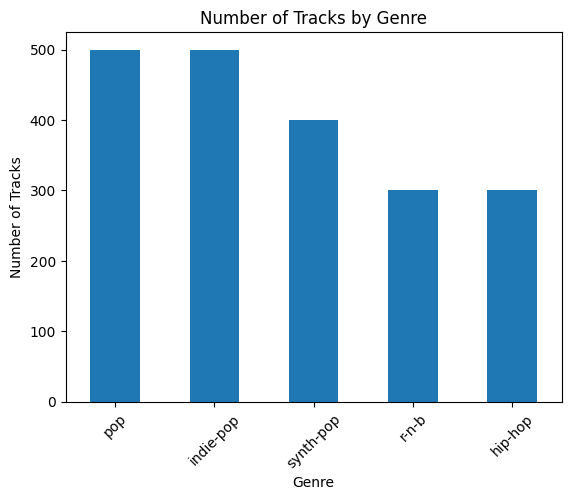

In [10]:
# Genre distribution bar chart (Lab 1 style)
frequency_genre.plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.title("Number of Tracks by Genre")
plt.xticks(rotation=45)
plt.show()

### 2.3 Distribution Analysis for Numerical Attributes

Following Lab 1 Section C, we examine histograms and box plots. Following Lab 4, we examine features in named groups.

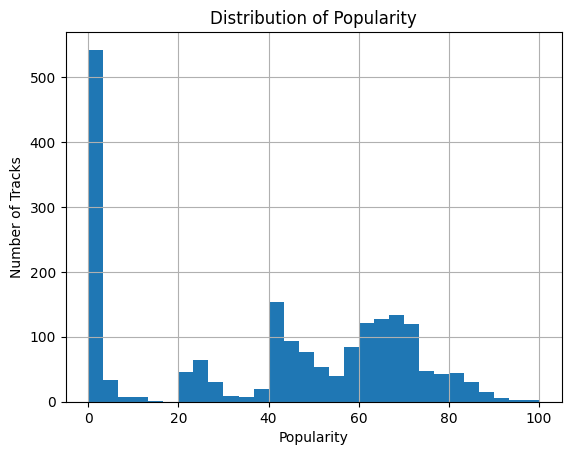

In [11]:
# Histogram of popularity (Lab 1 style)
df["popularity"].hist(bins=30)
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")
plt.title("Distribution of Popularity")
plt.show()

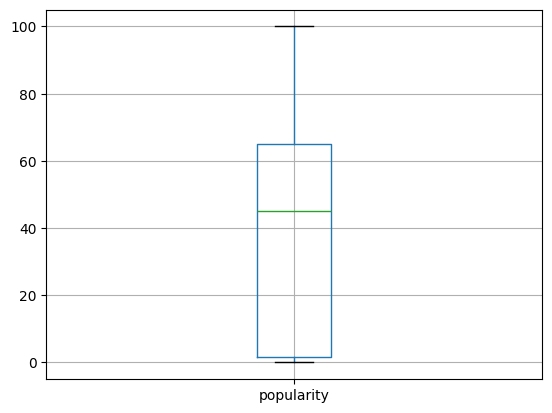

In [12]:
# Boxplot of popularity
df.boxplot(column="popularity")
plt.show()

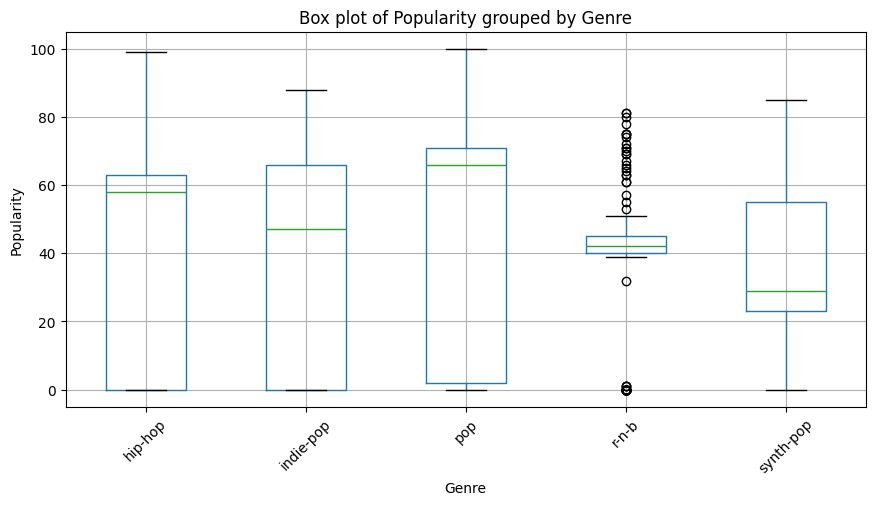

In [13]:
# Popularity by genre — boxplot grouped by categorical attribute (Lab 1 style)
df.boxplot(column="popularity", by="track_genre", rot=45, figsize=(10, 5))
plt.title("Box plot of Popularity grouped by Genre")
plt.suptitle("")
plt.xlabel("Genre")
plt.ylabel("Popularity")
plt.show()

,danceability,energy,speechiness,acousticness
count,1960.000000,1960.000000,2000.000000,2000.000000
mean,0.635897,0.632489,0.078466,0.297378
std,0.138298,0.189087,0.076223,0.279793
min,0.185000,0.090900,0.022100,0.000007
25%,0.548000,0.507750,0.034475,0.052475
50%,0.646000,0.644000,0.047500,0.195500
75%,0.738000,0.780000,0.084950,0.490250
max,0.953000,0.996000,0.515000,0.990000


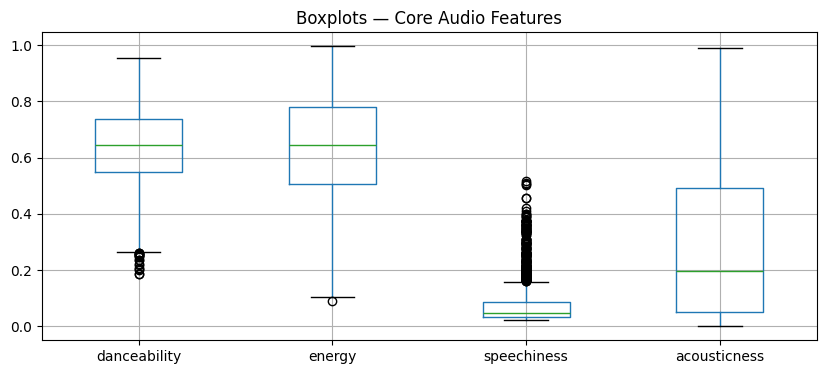

In [14]:
# Audio feature group 1: core audio features — describe + boxplot (Lab 4 slice style)
group1_cols = ["danceability", "energy", "speechiness", "acousticness"]
display(df[group1_cols].describe())
df[group1_cols].boxplot(figsize=(10, 4))
plt.title("Boxplots — Core Audio Features")
plt.show()

,instrumentalness,liveness,valence,loudness
count,2000.000000,2000.000000,2000.000000,1961.000000
mean,0.030269,0.180715,0.539963,400.575884
std,0.119946,0.149938,0.236062,18065.717039
min,0.000000,0.009860,0.035900,-21.089000
25%,0.000000,0.093775,0.353000,-8.988000
50%,0.000007,0.121000,0.536000,-6.924000
75%,0.000638,0.221250,0.730000,-5.390000
max,0.962000,0.986000,0.990000,800000.000000


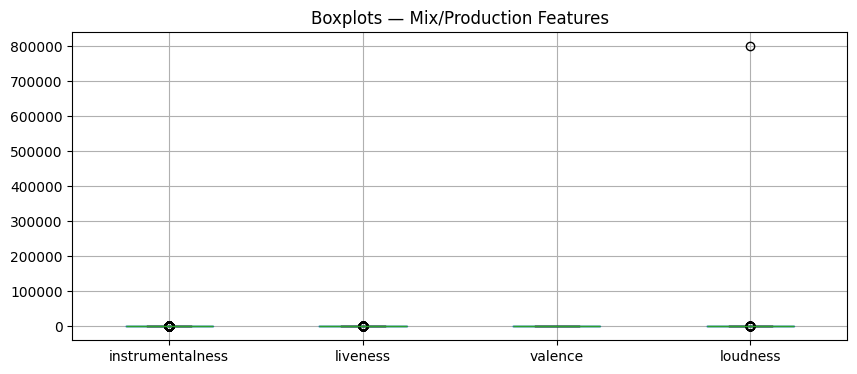

In [15]:
# Audio feature group 2: mix/production features (Lab 4 slice style)
group2_cols = ["instrumentalness", "liveness", "valence", "loudness"]
display(df[group2_cols].describe())
df[group2_cols].boxplot(figsize=(10, 4))
plt.title("Boxplots — Mix/Production Features")
plt.show()

,tempo,duration_ms,key,mode,time_signature
count,1960.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,120.040092,217806.433000,5.295500,0.637500,3.912000
std,28.520528,56804.759189,3.567148,0.480842,0.425848
min,51.037000,60000.000000,0.000000,0.000000,1.000000
25%,96.956000,181210.000000,2.000000,0.000000,4.000000
50%,118.711500,211346.000000,5.000000,1.000000,4.000000
75%,139.746250,246069.750000,8.000000,1.000000,4.000000
max,205.895000,561133.000000,11.000000,1.000000,5.000000


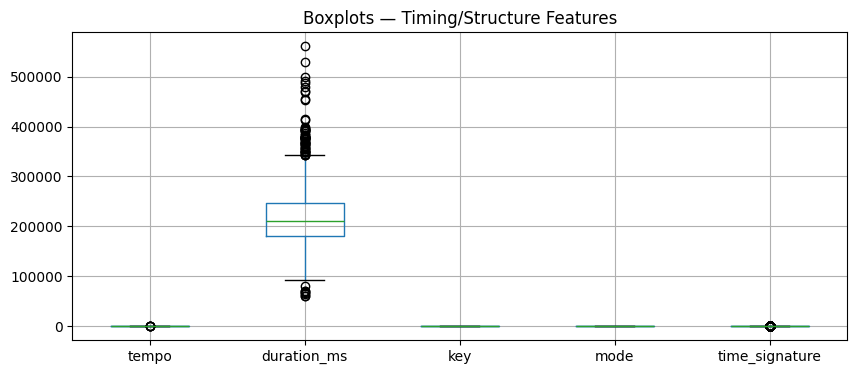

In [16]:
# Audio feature group 3: timing/structure features (Lab 4 slice style)
group3_cols = ["tempo", "duration_ms", "key", "mode", "time_signature"]
display(df[group3_cols].describe())
df[group3_cols].boxplot(figsize=(10, 4))
plt.title("Boxplots — Timing/Structure Features")
plt.show()

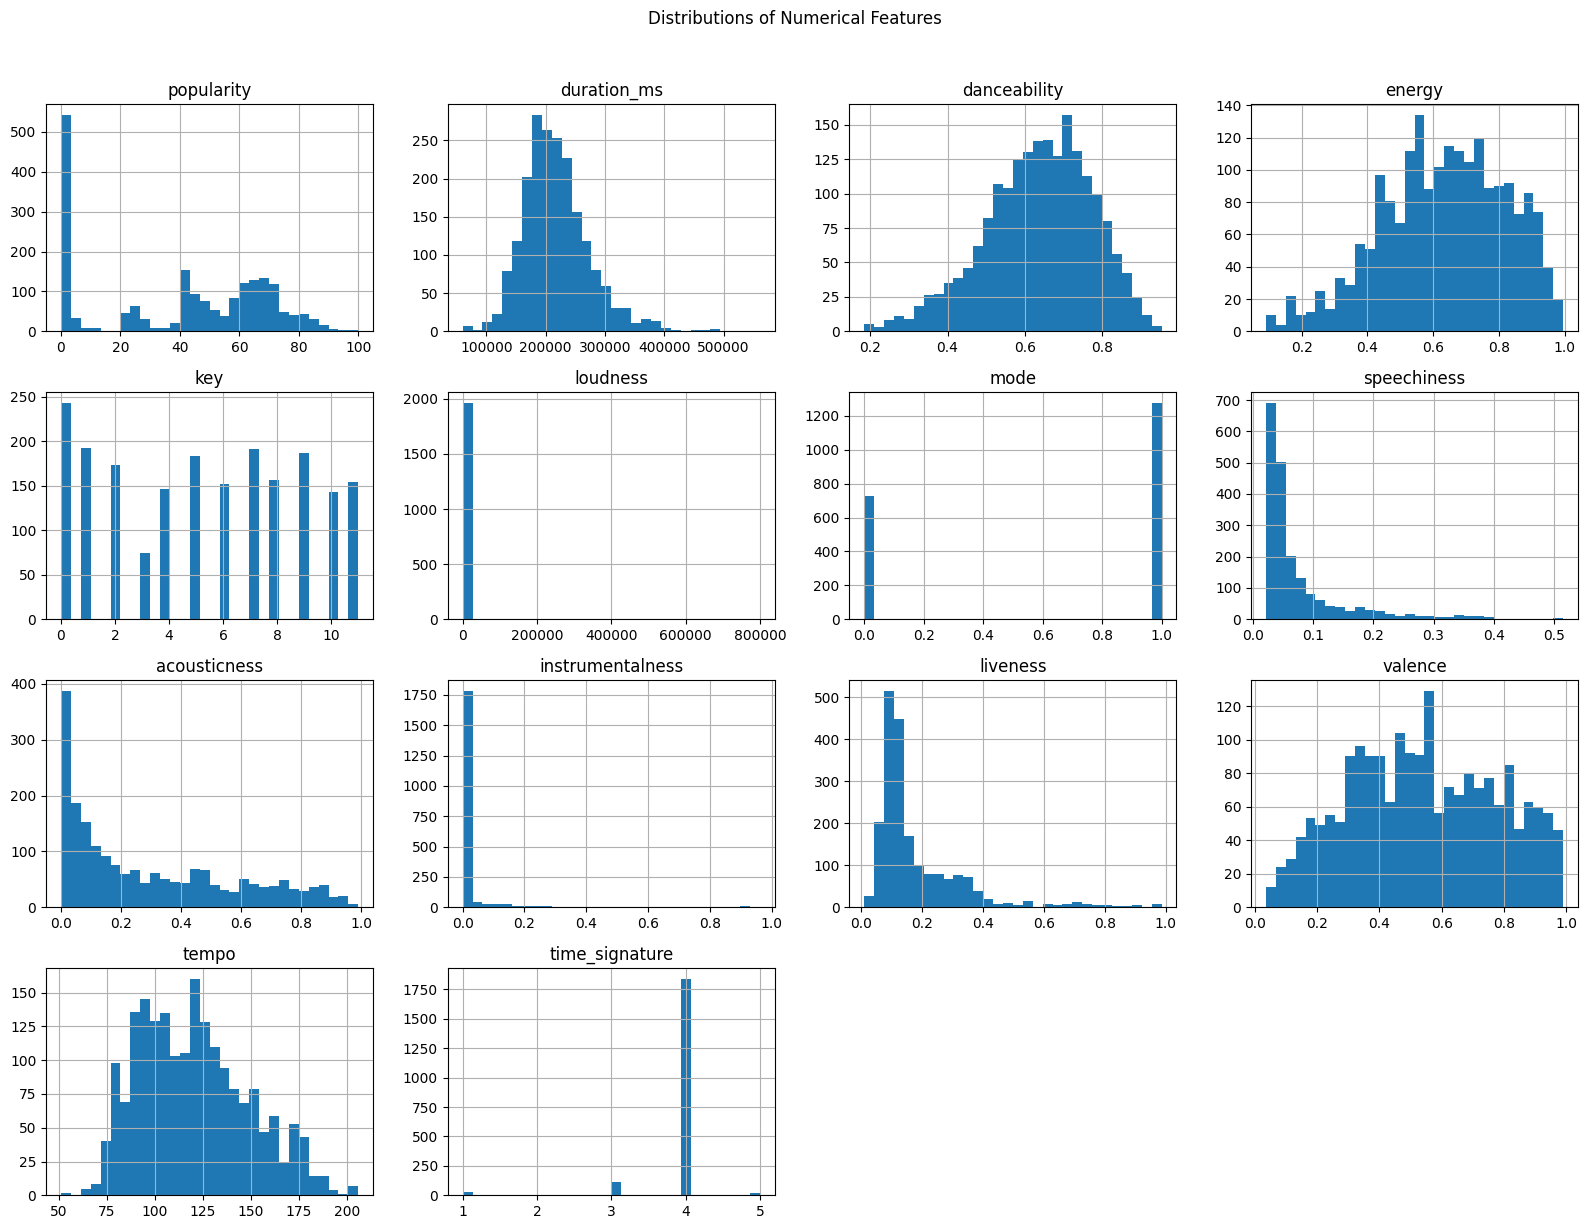

In [17]:
# Histograms of all numerical features (Lab 1 style)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].hist(bins=30, figsize=(16, 12))
plt.suptitle("Distributions of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

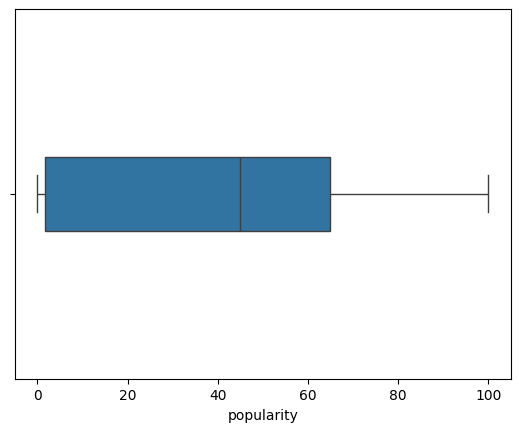

In [18]:
# Seaborn box plot for popularity (Lab 1 Section D style)
sns.boxplot(x=df["popularity"], orient="v", width=0.2)
plt.show()

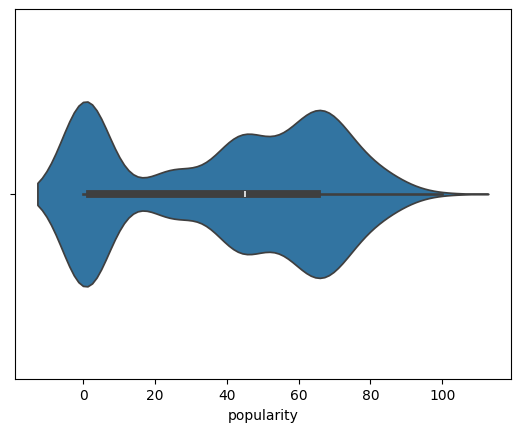

In [19]:
# Violin plot of popularity (Lab 1 Section D style)
sns.violinplot(x=df["popularity"], orient="v", width=0.5)
plt.show()

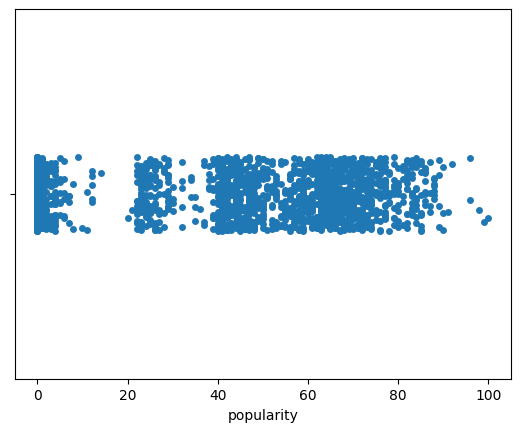

In [20]:
# Strip plot of popularity (Lab 1 Section D style)
sns.stripplot(x=df["popularity"], jitter=True, orient="v")
plt.show()

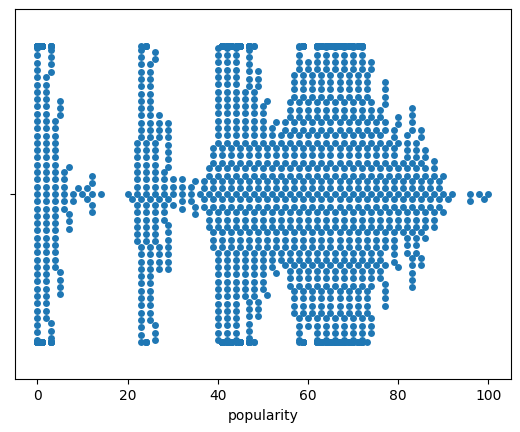

In [21]:
# Swarm plot of popularity (Lab 1 Section D style)
sns.swarmplot(x=df["popularity"], orient="v")
plt.show()

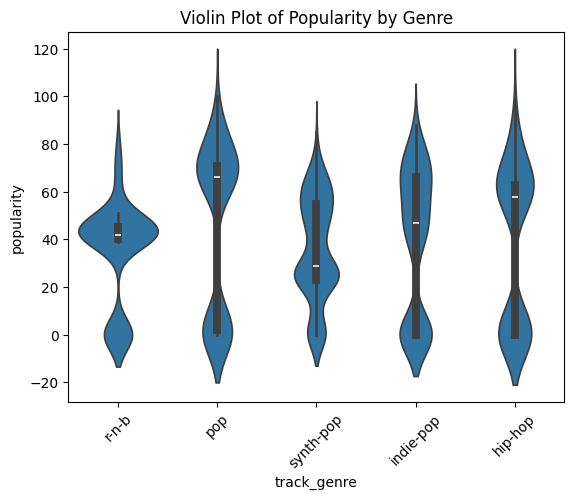

In [22]:
# Violin plot of popularity by genre (Lab 1 grouped violin style)
sns.violinplot(data=df, x="track_genre", y="popularity")
plt.title("Violin Plot of Popularity by Genre")
plt.xticks(rotation=45)
plt.show()

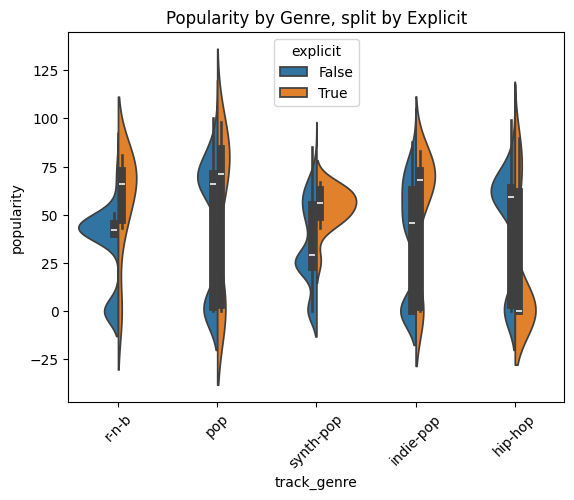

In [23]:
# Split violin plot: popularity by genre, split by explicit (Lab 1 split violin style)
sns.violinplot(data=df, x="track_genre", y="popularity",
               hue="explicit", split=True)
plt.title("Popularity by Genre, split by Explicit")
plt.xticks(rotation=45)
plt.show()

### 2.4 Correlation Heatmap

Following Lab 1, we examine pairwise correlations between numerical attributes.

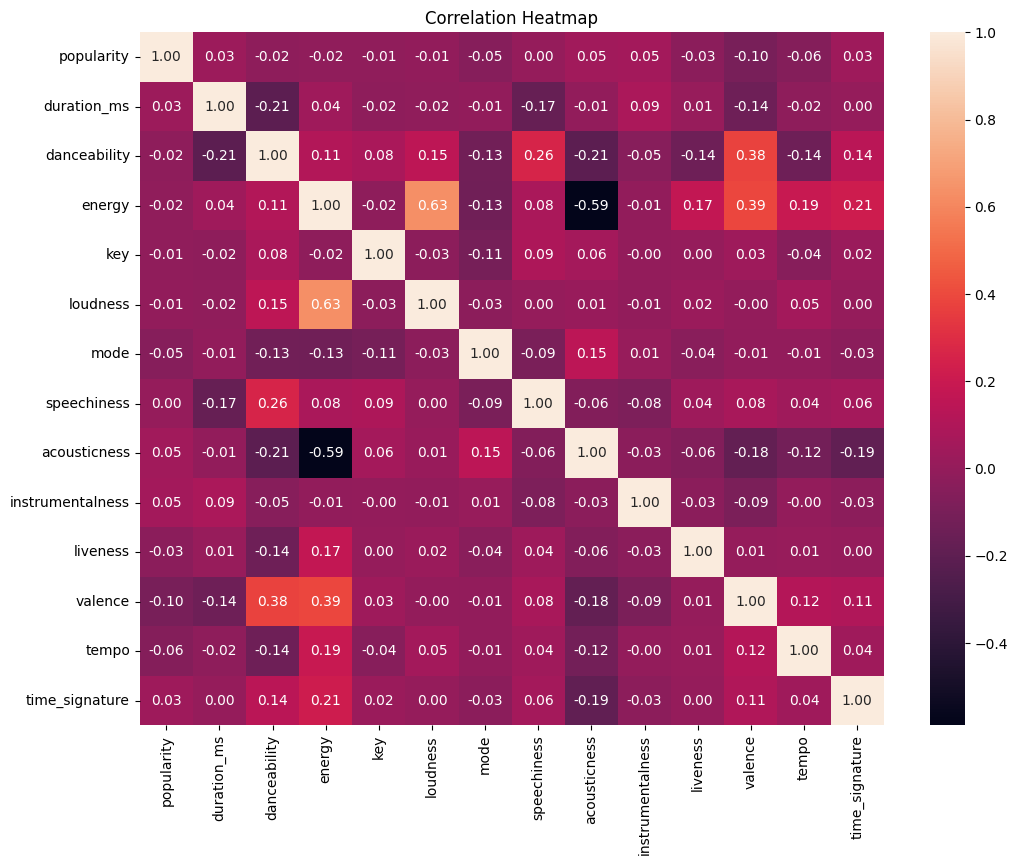


Correlation with popularity:


popularity          1.000000
instrumentalness    0.052461
acousticness        0.049778
time_signature      0.032678
duration_ms         0.026282
speechiness         0.004288
loudness           -0.010803
key                -0.013315
energy             -0.017372
danceability       -0.023186
liveness           -0.033469
mode               -0.050896
tempo              -0.056942
valence            -0.100355
Name: popularity, dtype: float64

In [25]:
# Correlation heatmap (Lab 1 style)
plt.figure(figsize=(12, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with popularity:")
display(df[numeric_cols].corr()["popularity"].sort_values(ascending=False))

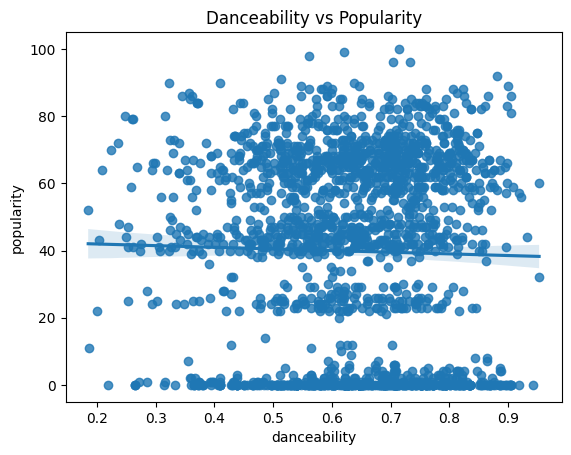

In [27]:
# Scatter plot with regression line — danceability vs popularity (Lab 1 regplot style)
sns.regplot(data=df, x="danceability", y="popularity")
plt.title("Danceability vs Popularity")
plt.show()

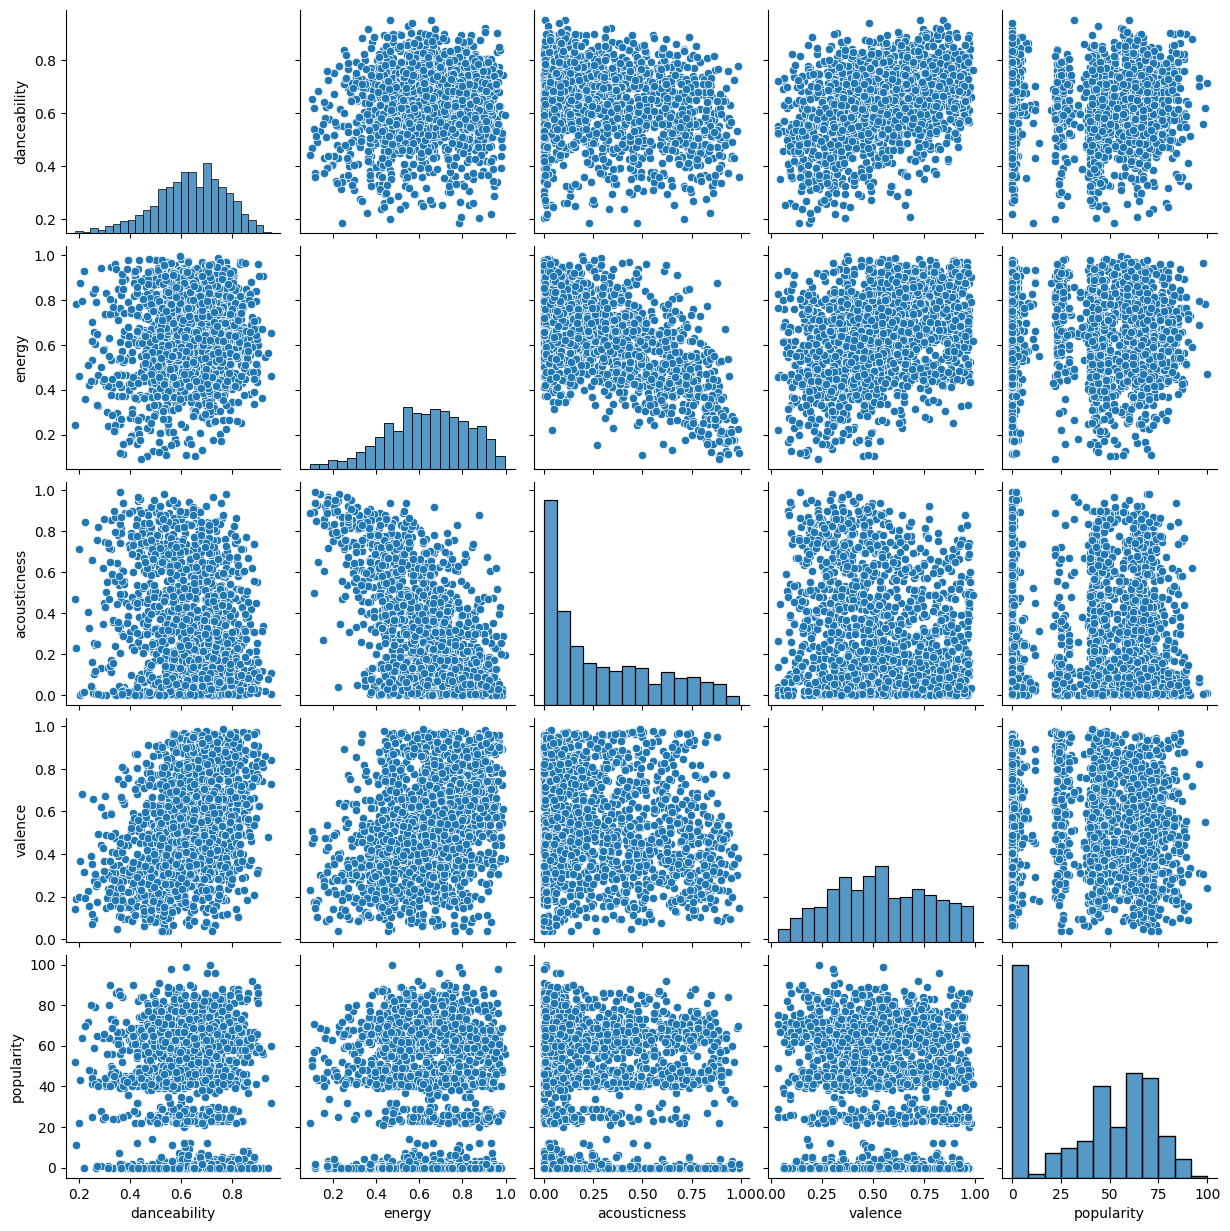

In [28]:
# Pair plot of key audio features (Lab 1 pairplot style)
sns.pairplot(data=df[["danceability","energy","acousticness","valence","popularity"]].dropna())
plt.show()

### 2.5 Distribution Analysis for Categorical Attributes

Following Lab 1 Section E, we examine the relationship between categorical attributes and popularity using pivot tables and stacked charts.

          popularity
explicit            
False      39.876005
True       39.238532


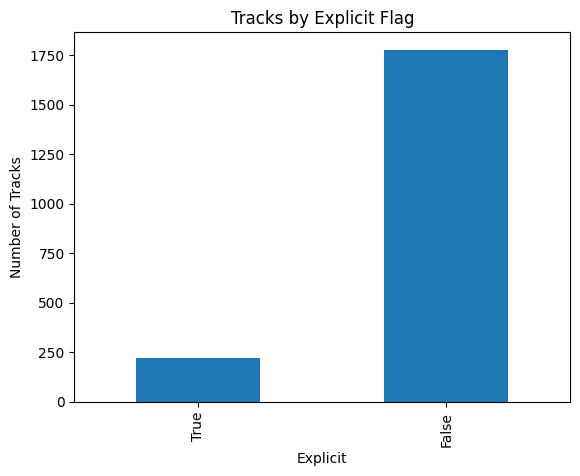

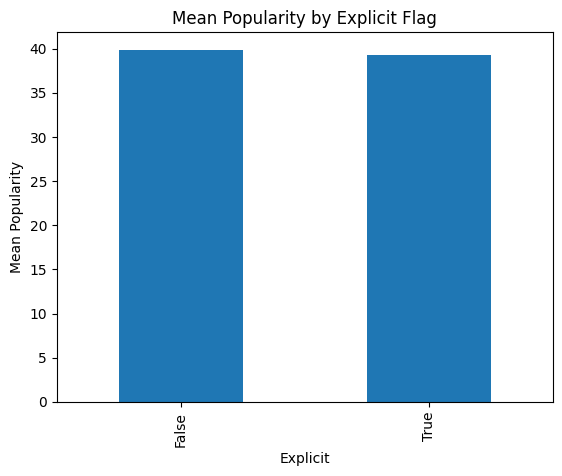

In [29]:
# Pivot table: mean popularity by explicit flag (Lab 1 pivot table + lambda style)
# explicit is boolean so we map True->1, False->0 for the aggfunc, mirroring Lab 1's lambda map
pivot_table_EP = df.pivot_table(
    values="popularity",
    index="explicit",
    aggfunc=lambda x: x.mean()
)
print(pivot_table_EP)

# Plot the frequency table for explicit
frequency_explicit.plot(kind="bar")
plt.xlabel("Explicit")
plt.ylabel("Number of Tracks")
plt.title("Tracks by Explicit Flag")
plt.show()

# Plot pivot table
pivot_table_EP.plot(kind="bar")
plt.xlabel("Explicit")
plt.ylabel("Mean Popularity")
plt.title("Mean Popularity by Explicit Flag")
plt.legend().set_visible(False)
plt.show()

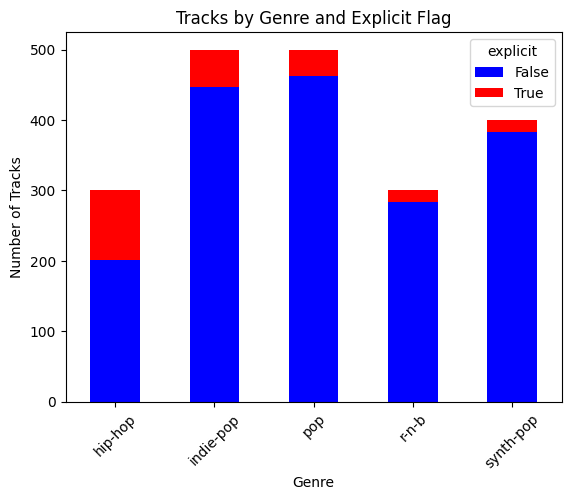

In [30]:
# Crosstab: genre vs explicit — stacked bar chart (Lab 1 crosstab style)
crosstab_GE = pd.crosstab(df["track_genre"], df["explicit"])
crosstab_GE.plot(kind="bar", stacked=True, color=["blue", "red"])
plt.ylabel("Number of Tracks")
plt.xlabel("Genre")
plt.title("Tracks by Genre and Explicit Flag")
plt.xticks(rotation=45)
plt.show()

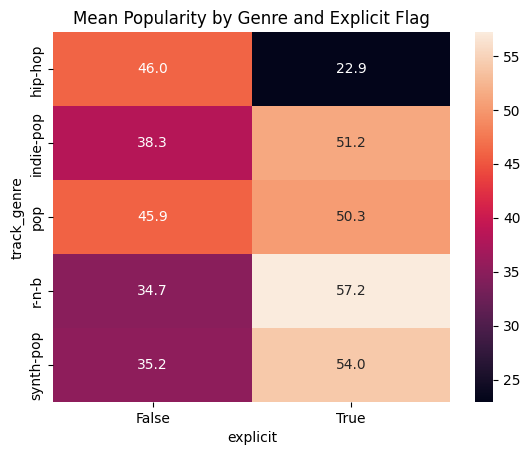

In [31]:
# Pivot table: mean popularity by genre and explicit — heatmap (Lab 1 heatmap style)
pivot_table_GE = df.pivot_table(
    values="popularity",
    index="track_genre",
    columns="explicit",
    aggfunc=lambda x: x.mean()
)
sns.heatmap(pivot_table_GE, annot=True, fmt=".1f")
plt.title("Mean Popularity by Genre and Explicit Flag")
plt.show()

### 2.6 Data Cleaning

Following Lab 2, we make a copy of the dataset before any transformations and handle identified issues.

In [32]:
# Keep a copy of the original dataset before any transformation (Lab 2 style)
df_original = df.copy()

# Drop identifier column — contains no useful information (Lab 2 Section B)
# Note: this dataset has track_id only; there are no artists/album_name/track_name columns
df_clean = df.copy()
df_clean.drop(columns=["track_id"], inplace=True)

# Cast explicit boolean to int (0/1) so pipelines treat it as numeric
df_clean["explicit"] = df_clean["explicit"].astype(int)

# Treat the one unrealistic loudness value (800000 dB) as missing (Lab 2 outlier treatment)
# Normal Spotify loudness is in the range -60 to 0 dB
print("Loudness outlier row:")
display(df_clean[df_clean["loudness"] > 5][["loudness", "track_genre"]])
df_clean.loc[df_clean["loudness"] > 5, "loudness"] = np.nan

# Check for zeros that may represent missing values (Lab 5 style)
# In this dataset zeros in instrumentalness, key, mode are musically valid — not missing
print("\nZero check for key numeric columns:")
for col in ["popularity", "instrumentalness", "key", "mode"]:
    print(f"  {col}: {(df_clean[col] == 0).sum()} zeros — ", end="")
    if col == "popularity":
        print("valid (very unpopular tracks), 40 NaNs are the true missing values")
    elif col == "instrumentalness":
        print("valid (tracks with vocals score near 0)")
    elif col in ["key", "mode"]:
        print("valid (key=0 means C, mode=0 means minor)")

print("\nMissing values after cleaning:")
display(df_clean.isna().sum())

Loudness outlier row:


,loudness,track_genre
1289,800000.0,pop



Zero check for key numeric columns:
  popularity: 422 zeros — valid (very unpopular tracks), 40 NaNs are the true missing values
  instrumentalness: 818 zeros — valid (tracks with vocals score near 0)
  key: 243 zeros — valid (key=0 means C, mode=0 means minor)
  mode: 725 zeros — valid (key=0 means C, mode=0 means minor)

Missing values after cleaning:


popularity          40
duration_ms          0
explicit             0
danceability        40
energy              40
key                  0
loudness            40
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
time_signature       0
track_genre          0
dtype: int64

In [33]:
# The 40 NaN rows have missing values across popularity, danceability, energy,
# loudness and tempo simultaneously — they are the same 40 rows.
# Since they are missing the target variable (popularity) and several features,
# we drop them rather than impute. (Lab 2: no column has > 25% missing, so no columns dropped.)
print("Rows missing popularity:", df_clean["popularity"].isna().sum())
print("Are those same rows also missing danceability?",
      df_clean[df_clean["popularity"].isna()]["danceability"].isna().all())

df_clean = df_clean.dropna(subset=["popularity", "danceability", "energy", "tempo"])
print("\nShape after dropping incomplete rows:", df_clean.shape)
print("\nRemaining missing values:")
display(df_clean.isna().sum())

Rows missing popularity: 40
Are those same rows also missing danceability? True

Shape after dropping incomplete rows: (1960, 16)

Remaining missing values:


popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

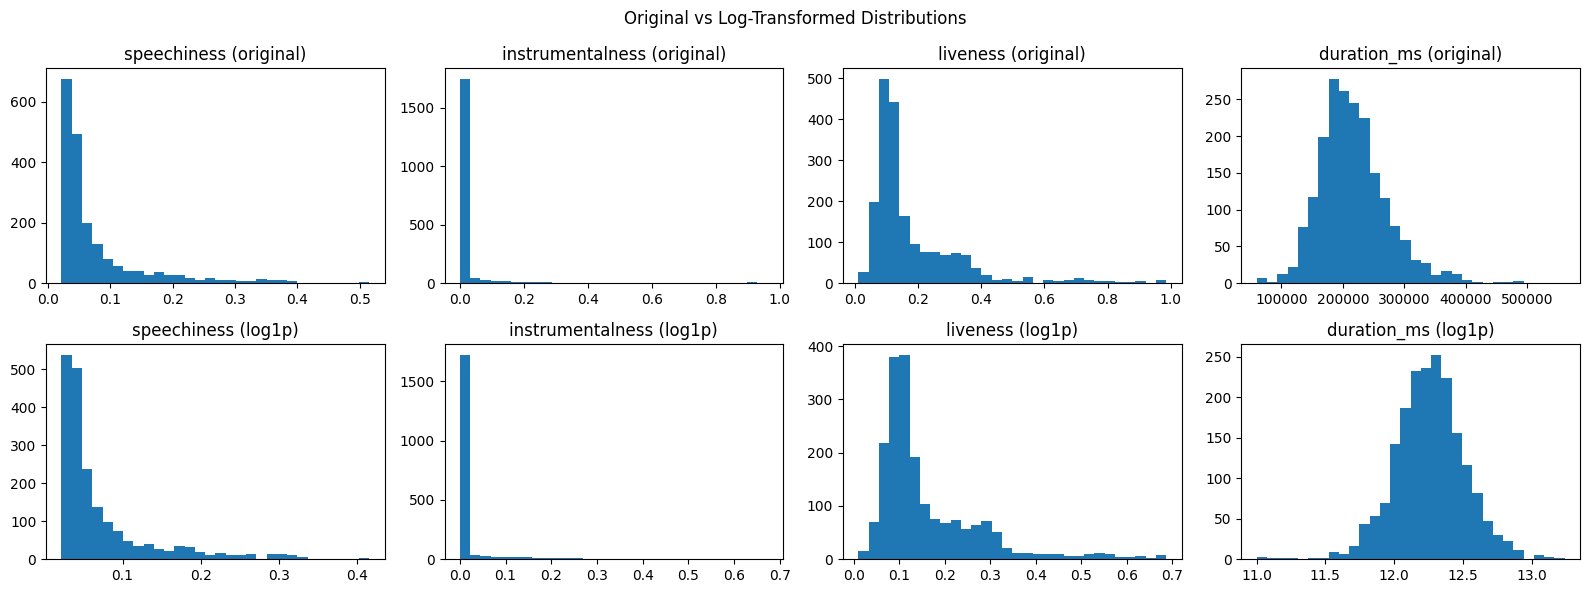

In [35]:
# Before/after histograms for the most skewed features (Lab 2 Section E style)
# speechiness, instrumentalness and liveness are highly right-skewed
skewed_cols = ["speechiness", "instrumentalness", "liveness", "duration_ms"]

fig, axes = plt.subplots(2, len(skewed_cols), figsize=(16, 6))
for i, col in enumerate(skewed_cols):
    axes[0, i].hist(df_clean[col], bins=30)
    axes[0, i].set_title(f"{col} (original)")
    axes[1, i].hist(np.log1p(df_clean[col]), bins=30)
    axes[1, i].set_title(f"{col} (log1p)")
plt.suptitle("Original vs Log-Transformed Distributions")
plt.tight_layout()
plt.show()

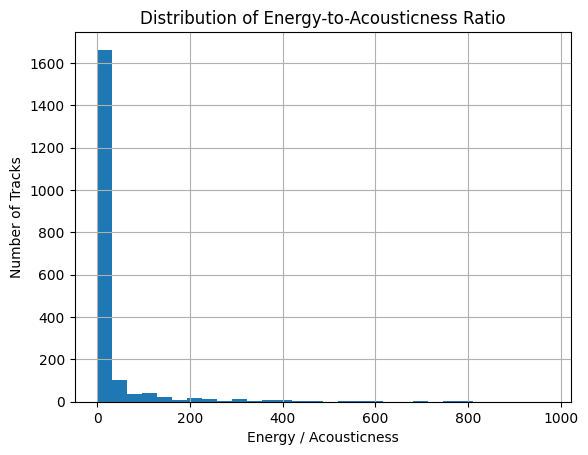

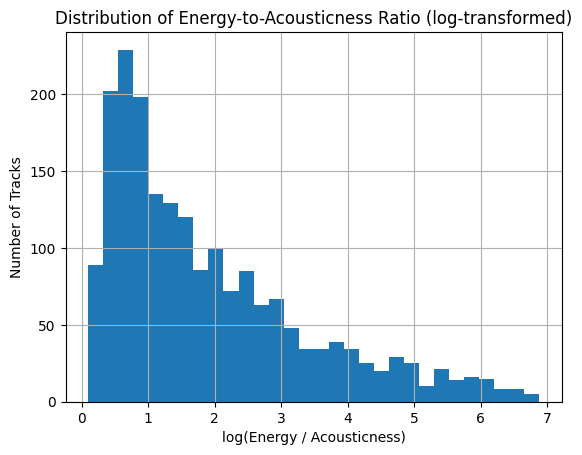

In [37]:
# Create a derived feature: energy_to_acousticness ratio (Lab 2 Section F style)
# Tracks that are high energy but low acoustic are likely produced/electronic
# This mirrors Lab 2's TotalIncome derived feature
df_clean["energy_acoustic_ratio"] = df_clean["energy"] / (df_clean["acousticness"] + 0.001)

df_clean["energy_acoustic_ratio"].hist(bins=30)
plt.xlabel("Energy / Acousticness")
plt.ylabel("Number of Tracks")
plt.title("Distribution of Energy-to-Acousticness Ratio")
plt.show()

# Apply log transform to reduce skew (Lab 2 style)
df_clean["energy_acoustic_ratio"] = np.log1p(df_clean["energy_acoustic_ratio"])
df_clean["energy_acoustic_ratio"].hist(bins=30)
plt.xlabel("log(Energy / Acousticness)")
plt.ylabel("Number of Tracks")
plt.title("Distribution of Energy-to-Acousticness Ratio (log-transformed)")
plt.show()

In [38]:
# Save the prepared dataset (Lab 2 Section G style)
df_clean.to_csv("tracks2026_prepared.csv", index=False)
print("Prepared dataset saved. Shape:", df_clean.shape)
display(df_clean.head())

Prepared dataset saved. Shape: (1960, 17)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,energy_acoustic_ratio
0,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b,0.876948
1,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop,1.882929
2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop,1.178655
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop,2.808360
4,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop,1.316891


**Observations from EDA:**
- The dataset has 2,000 tracks across 5 genres: pop (500), indie-pop (500), synth-pop (400), r-n-b (300), hip-hop (300) — slightly imbalanced.
- `explicit` is overwhelmingly False (1,777 vs 223 tracks).
- `popularity` has a bimodal distribution: many tracks score 0 (very obscure) and many score in the 50–80 range.
- The 40 NaN rows are missing across popularity, danceability, energy, loudness and tempo simultaneously — they were dropped rather than imputed since the target itself is missing.
- One loudness value of 800,000 dB is a clear data entry error; treated as missing and imputed by the pipeline.
- `speechiness`, `instrumentalness` and `liveness` are highly right-skewed; log transformation improves their distribution.
- `key`, `mode` and `time_signature` are categorical integers — one-hot encoded in pipelines.

---
**→ Add your own deeper interpretation here.**

## 3. Clustering (Descriptive Analytics)

Following Lab 3, we construct clustering pipelines using K-Means and DBSCAN.

### 3.1 Data Preparation for Clustering

In [39]:
# Assignment requirement: drop track_genre for clustering
cluster_df = df_clean.drop(columns=["track_genre"])

# Separate column groups (Lab 3 + Lab 4 column grouping style)
# Columns with high skew: apply log transform then MinMaxScaler (Lab 3 FunctionTransformer style)
# Columns with outliers only: RobustScaler
# Remaining numerical: StandardScaler
# Categorical integers (key, time_signature): OneHotEncoder

log_cols      = ["speechiness", "instrumentalness", "liveness", "duration_ms"]
robust_cols   = ["loudness"]
standard_cols = ["danceability", "energy", "acousticness", "valence", "tempo",
                 "energy_acoustic_ratio", "explicit", "mode"]
ohe_cols      = ["key", "time_signature"]

print("Log-transform cols:", log_cols)
print("RobustScaler cols:", robust_cols)
print("StandardScaler cols:", standard_cols)
print("OneHotEncoder cols:", ohe_cols)

Log-transform cols: ['speechiness', 'instrumentalness', 'liveness', 'duration_ms']
RobustScaler cols: ['loudness']
StandardScaler cols: ['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'energy_acoustic_ratio', 'explicit', 'mode']
OneHotEncoder cols: ['key', 'time_signature']


In [40]:
# Build preprocessing pipeline for clustering (Lab 3 Pipeline + ColumnTransformer style)
# Using FunctionTransformer(np.log1p) + MinMaxScaler for skewed cols (Lab 3 petal_pipeline style)
log_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scaler", MinMaxScaler())
])

robust_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

standard_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cluster_preprocess = ColumnTransformer(
    transformers=[
        ("log_cols",      log_pipeline,      log_cols),
        ("robust_cols",   robust_pipeline,   robust_cols),
        ("standard_cols", standard_pipeline, standard_cols),
        ("ohe_cols",      OneHotEncoder(handle_unknown="ignore", sparse_output=False), ohe_cols)
    ]
)

# Visualise the pipeline (Lab 3 set_config style)
set_config(display="diagram")
cluster_preprocess

ColumnTransformer(transformers=[('log_cols',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', MinMaxScaler())]),
                                 ['speechiness', 'instrumentalness', 'liveness',
                                  'duration_ms']),
                                ('robust_cols',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['loudness']),
                                ('standard_cols',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['danceability', 'energy', 'acousticness',
                                  'valence', 'tempo', 'energy_acoustic_ratio',
                                  'explicit', 'mode']),
                                ('ohe_cols',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['key', 'time_signature'])])

In [41]:
X_cluster = cluster_preprocess.fit_transform(cluster_df)

# Keep genre codes for external comparison after clustering (Lab 3 cluster analysis)
genre_codes = pd.factorize(df_clean["track_genre"])[0]

print("Cluster matrix shape:", X_cluster.shape)

Cluster matrix shape: (1960, 29)


### 3.2 K-Means Clustering

Following Lab 3 Section D, we use an elbow plot and silhouette scores to determine a suitable value of k.

,k,inertia,silhouette,ARI_vs_genre
0,2,15448.207819,0.180596,0.021636
1,3,13552.449005,0.203507,0.035697
2,4,12285.613744,0.157392,0.042176
3,5,11322.489079,0.161052,0.050114
4,6,10830.918317,0.151981,0.046739
5,7,10406.061135,0.141031,0.042915
6,8,10012.784417,0.128568,0.043153
7,9,9714.008729,0.131748,0.041266
8,10,9381.578590,0.131043,0.038954


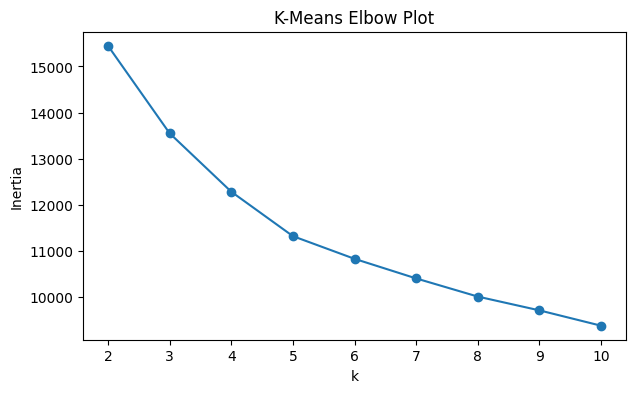

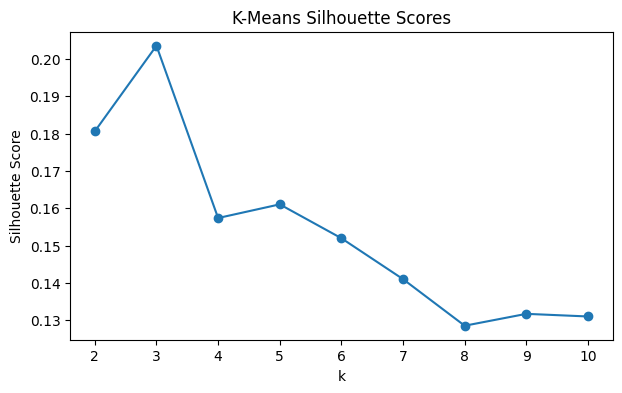

In [42]:
# Evaluate several k values using inertia and silhouette (Lab 3 style)
k_values = range(2, 11)
kmeans_results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    kmeans_results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_cluster, labels),
        "ARI_vs_genre": adjusted_rand_score(genre_codes, labels)
    })

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results)

# Elbow plot (Lab 3 style)
plt.figure(figsize=(7, 4))
plt.plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
plt.title("K-Means Elbow Plot")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
plt.title("K-Means Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

In [43]:
# Compare at least two values of k (specification requirement)
for k in [3, 5]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    print(f"\nK-Means k={k}")
    print("Silhouette:", round(silhouette_score(X_cluster, labels), 3))
    print("ARI vs genre:", round(adjusted_rand_score(genre_codes, labels), 3))
    display(pd.crosstab(labels, df_clean["track_genre"], normalize="index").round(2))


K-Means k=3
Silhouette: 0.204
ARI vs genre: 0.036


track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
0,0.15,0.18,0.24,0.15,0.28
1,0.44,0.24,0.17,0.07,0.08
2,0.05,0.37,0.29,0.18,0.12



K-Means k=5
Silhouette: 0.161
ARI vs genre: 0.05


track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
0,0.05,0.41,0.28,0.15,0.11
1,0.07,0.27,0.16,0.14,0.36
2,0.45,0.24,0.17,0.07,0.08
3,0.21,0.12,0.37,0.11,0.19
4,0.11,0.21,0.20,0.23,0.25


In [44]:
# Scatterplot function for visualising clusters (Lab 3 Section C)
colors = np.array(["orange", "blue", "lime", "khaki", "pink", "green", "purple"])

def clustering_scatterplot(points, labels, centers, title):
    n_clusters = len(np.unique(labels[labels >= 0]))
    for i in range(n_clusters):
        plt.scatter(points[labels == i, 0], points[labels == i, 1],
                    c=colors[i % colors.size], label=f"cluster {i}", s=15)
    if -1 in labels:
        plt.scatter(points[labels == -1, 0], points[labels == -1, 1],
                    c="black", label="noise", s=10, alpha=0.3)
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], c="r", marker="*", s=500)
    plt.title(title)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")

In [45]:
# Train final K-Means model using a Pipeline (Lab 3 Section D style)
chosen_k = 5  # justify this choice based on elbow plot and silhouette scores above

pipe_km = Pipeline(steps=[
    ("preprocess", cluster_preprocess),
    ("kMeans", KMeans(n_clusters=chosen_k, n_init=10, max_iter=300, random_state=RANDOM_STATE))
])

set_config(display="diagram")
pipe_km

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('log_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['speechiness',
                                                   'instrumentalness',
                                                   'liveness', 'duration_ms']),
                                                 ('robust_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='m...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['danceability', 'energy',
                                                   'acousticness', 'valence',
                                                   'tempo',
                                                   'energy_acoustic_ratio',
                                                   'explicit', 'mode']),
                                                 ('ohe_cols',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['key', 'time_signature'])])),
                ('kMeans', KMeans(n_clusters=5, n_init=10, random_state=42))])

In [46]:
clustering_model = pipe_km.fit(cluster_df)
preprocessed_data = clustering_model["preprocess"].transform(cluster_df)
kmeans_labels = clustering_model["kMeans"].labels_

MDS transformation complete


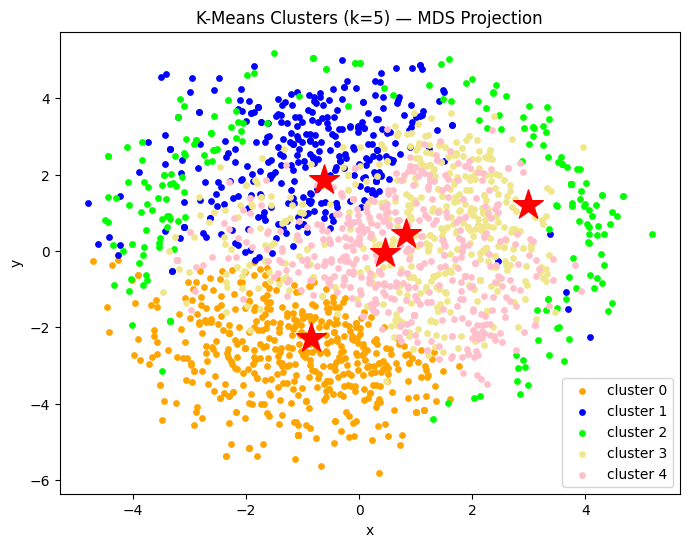

In [47]:
# Append cluster centers and project with MDS (Lab 3 Section E1)
data_and_centers = np.r_[preprocessed_data, clustering_model["kMeans"].cluster_centers_]

XYcoordinates = manifold.MDS(n_components=2, normalized_stress="auto",
                              random_state=RANDOM_STATE).fit_transform(data_and_centers)
print("MDS transformation complete")

plt.figure(figsize=(8, 6))
clustering_scatterplot(
    points=XYcoordinates[:-chosen_k, :],
    labels=kmeans_labels,
    centers=XYcoordinates[-chosen_k:, :],
    title=f"K-Means Clusters (k={chosen_k}) — MDS Projection"
)
plt.show()

t-SNE transformation complete


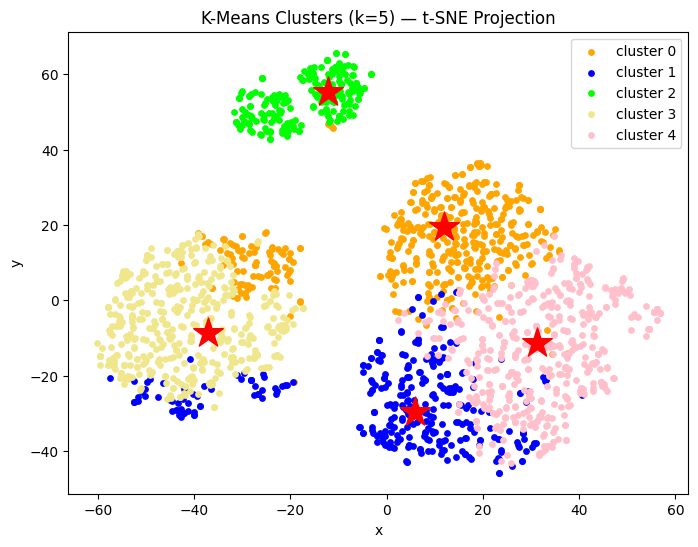

In [48]:
# t-SNE visualisation (Lab 3 Section E2)
XYcoordinates_tsne = manifold.TSNE(n_components=2, random_state=RANDOM_STATE).fit_transform(data_and_centers)
print("t-SNE transformation complete")

plt.figure(figsize=(8, 6))
clustering_scatterplot(
    points=XYcoordinates_tsne[:-chosen_k, :],
    labels=kmeans_labels,
    centers=XYcoordinates_tsne[-chosen_k:, :],
    title=f"K-Means Clusters (k={chosen_k}) — t-SNE Projection"
)
plt.show()

In [49]:
# Cluster analysis: mean value of each attribute per cluster (Lab 3 Section F)
cluster_df_analysis = df_clean.copy()
cluster_df_analysis["cluster"] = pd.Series(kmeans_labels, index=cluster_df_analysis.index)

display(cluster_df_analysis.head())
display(cluster_df_analysis.tail())

print("\nMean attribute values per cluster:")
display(cluster_df_analysis.groupby("cluster").mean(numeric_only=True).round(3))

print("\nMost common genre per cluster:")
display(cluster_df_analysis.groupby("cluster")["track_genre"].agg(
    lambda x: x.value_counts().index[0]))

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,energy_acoustic_ratio,cluster
0,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b,0.876948,4
1,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop,1.882929,3
2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop,1.178655,3
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop,2.808360,1
4,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop,1.316891,3


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,energy_acoustic_ratio,cluster
1995,25.0,266133,0,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop,1.935720,4
1996,52.0,223236,0,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop,1.520358,4
1997,0.0,162009,0,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop,2.481626,1
1998,58.0,120000,0,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop,1.309333,3
1999,25.0,244026,0,0.746,0.570,7,-10.599,1,0.0389,0.6660,0.000005,0.3200,0.657,109.929,4,synth-pop,0.617654,4



Mean attribute values per cluster:


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,energy_acoustic_ratio
cluster,,,,,,,,,,,,,,,,
0,42.545,226123.735,0.006,0.535,0.421,5.326,-9.813,0.800,0.054,0.625,0.037,0.167,0.340,112.517,3.796,0.591
1,37.110,226574.583,0.000,0.554,0.790,4.429,-6.218,0.815,0.063,0.040,0.053,0.210,0.513,136.168,3.967,3.940
2,39.367,199433.893,1.000,0.721,0.637,5.349,-6.291,0.544,0.137,0.171,0.010,0.180,0.480,121.123,3.944,2.436
3,42.039,217982.554,0.000,0.691,0.695,5.823,-6.393,0.000,0.086,0.217,0.026,0.188,0.615,117.067,3.963,1.918
4,37.031,211090.061,0.000,0.703,0.670,5.302,-7.224,1.000,0.080,0.289,0.021,0.169,0.712,118.531,3.925,1.547



Most common genre per cluster:


cluster
0    indie-pop
1    synth-pop
2      hip-hop
3          pop
4    synth-pop
Name: track_genre, dtype: object

### 3.3 DBSCAN Clustering

In [50]:
# DBSCAN parameter search (Lab 3 style)
dbscan_results = []
for eps in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_cluster)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)
    sil = np.nan
    if n_clusters > 1:
        sil = silhouette_score(X_cluster, labels)
    dbscan_results.append({
        "eps": eps,
        "min_samples": 10,
        "n_clusters": n_clusters,
        "noise_ratio": round(noise_ratio, 3),
        "silhouette": sil
    })

display(pd.DataFrame(dbscan_results))

,eps,min_samples,n_clusters,noise_ratio,silhouette
0,1.5,10,18,0.807,-0.238201
1,2.0,10,4,0.131,0.094504
2,2.5,10,2,0.011,0.207196
3,3.0,10,2,0.000,0.220415
4,3.5,10,1,0.000,NaN
5,4.0,10,1,0.000,NaN


Clusters (excluding noise): 1
Noise ratio: 0.0


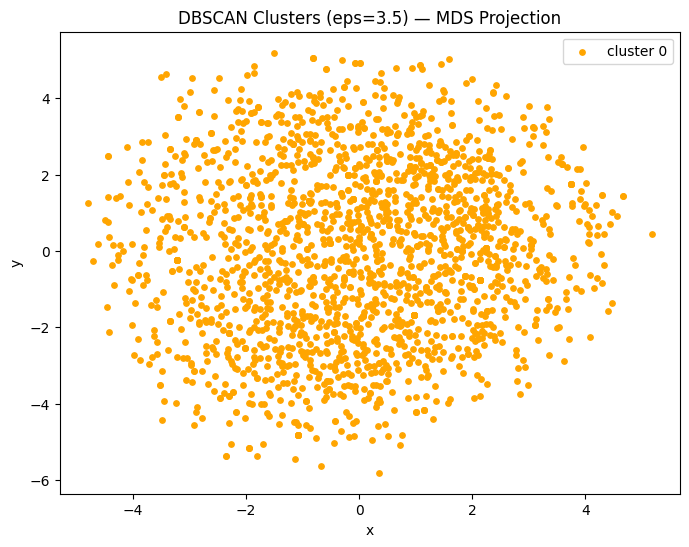


DBSCAN cluster vs genre cross-tabulation:


track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
0,0.15,0.25,0.25,0.15,0.2


In [51]:
# Visualise chosen DBSCAN solution (Lab 3 style)
chosen_eps = 3.5  # choose based on the table above
db_final = DBSCAN(eps=chosen_eps, min_samples=10)
db_labels = db_final.fit_predict(X_cluster)

print("Clusters (excluding noise):", len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise ratio:", round(np.mean(db_labels == -1), 3))

plt.figure(figsize=(8, 6))
clustering_scatterplot(
    points=XYcoordinates[:-chosen_k, :],
    labels=db_labels,
    centers=None,
    title=f"DBSCAN Clusters (eps={chosen_eps}) — MDS Projection"
)
plt.show()

print("\nDBSCAN cluster vs genre cross-tabulation:")
display(pd.crosstab(db_labels, df_clean["track_genre"], normalize="index").round(2))

### 3.4 Clustering Conclusion

**→ Add your own conclusion here following the Lab 3 style.** Discuss:
- Which value of k did you choose and why (elbow plot, silhouette scores)?
- Do clusters reveal meaningful structure — do they align with genres?
- How does K-Means compare to DBSCAN for this dataset?
- What does the cluster mean table tell you about each cluster's musical character?

## 4. Classification — Predicting Popularity Category

### 4.1 EDA for Classification

In [ ]:
# Create binary target using the median
# df_clean already has NaN rows dropped
# We are using the popularity median

class_df = df_clean.copy()
median_popularity = class_df["popularity"].median()
class_df["popularity_binary"] = (class_df["popularity"] > median_popularity).astype(int)

print("Median popularity:", median_popularity)
print("popularity_binary = 0 if popularity <=", median_popularity)
print("popularity_binary = 1 if popularity >", median_popularity)

print("\nClass distribution:")
display(class_df["popularity_binary"].value_counts())
display(class_df["popularity_binary"].value_counts(normalize=True).rename("proportion").round(3))

Median popularity: 45.0
popularity_binary = 0 if popularity <= 45.0
popularity_binary = 1 if popularity > 45.0

Class distribution:


popularity_binary
0    994
1    966
Name: count, dtype: int64

popularity_binary
0    0.507
1    0.493
Name: proportion, dtype: float64

Missing values in predictors:


duration_ms              0
explicit                 0
danceability             0
energy                   0
key                      0
loudness                 0
mode                     0
speechiness              0
acousticness             0
instrumentalness         0
liveness                 0
valence                  0
tempo                    0
time_signature           0
energy_acoustic_ratio    0
dtype: int64

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence
count,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000
mean,0.635897,0.632489,0.078251,0.298259,0.030313,0.181199,0.539731
std,0.138298,0.189087,0.076115,0.280367,0.120463,0.150613,0.236181
min,0.185000,0.090900,0.022100,0.000007,0.000000,0.009860,0.035900
25%,0.548000,0.507750,0.034400,0.052475,0.000000,0.093800,0.353000
50%,0.646000,0.644000,0.047400,0.195500,0.000007,0.121500,0.534500
75%,0.738000,0.780000,0.083925,0.491250,0.000647,0.222000,0.729000
max,0.953000,0.996000,0.515000,0.990000,0.962000,0.986000,0.990000


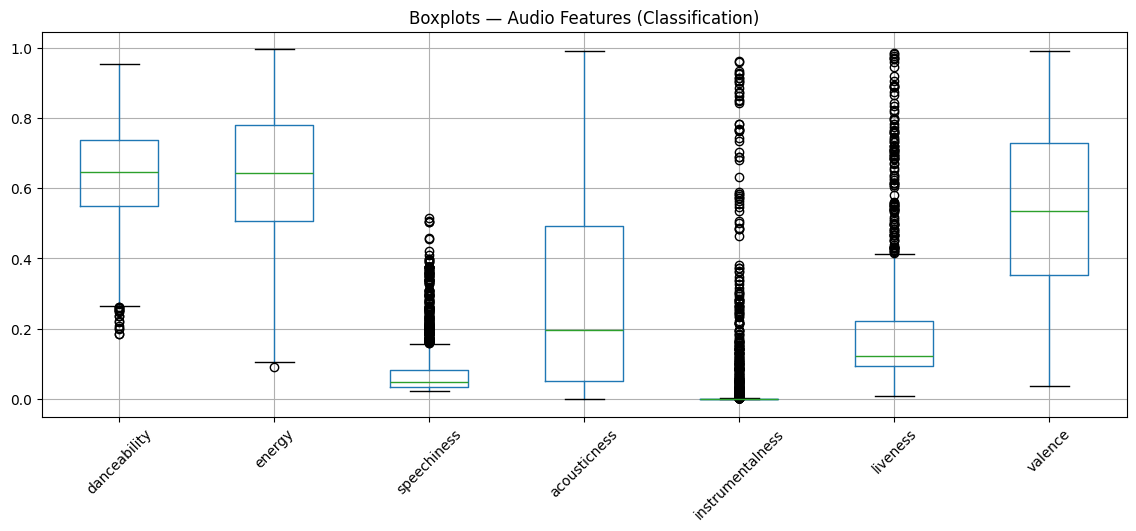

In [ ]:
# Preparing X and y and drop original popularity and track_genre
X_class = class_df.drop(columns=["popularity", "popularity_binary", "track_genre"])
y_class = class_df["popularity_binary"]
print("Missing values in predictors:")
display(X_class.isna().sum())

# Examining features in slices with boxplots
audio_cols = ["danceability","energy","speechiness","acousticness",
              "instrumentalness","liveness","valence"]
display(X_class[audio_cols].describe())
X_class[audio_cols].boxplot(figsize=(14, 5))
plt.title("Boxplots — Audio Features (Classification)")
plt.xticks(rotation=45)
plt.show() #TODO Instrumentalness has missing values

,loudness,tempo,duration_ms,key,mode,time_signature,explicit,energy_acoustic_ratio
count,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000
mean,-7.383006,120.040092,217716.381122,5.284694,0.636735,3.911735,0.111224,1.909568
std,2.876789,28.520528,56875.302052,3.556669,0.481063,0.428520,0.314490,1.488776
min,-21.089000,51.037000,60000.000000,0.000000,0.000000,1.000000,0.000000,0.097353
25%,-8.988750,96.956000,181201.500000,2.000000,0.000000,4.000000,0.000000,0.743857
50%,-6.924000,118.711500,211271.500000,5.000000,1.000000,4.000000,0.000000,1.451995
75%,-5.392250,139.746250,245986.750000,8.000000,1.000000,4.000000,0.000000,2.671008
max,-0.079000,205.895000,561133.000000,11.000000,1.000000,5.000000,1.000000,6.880406


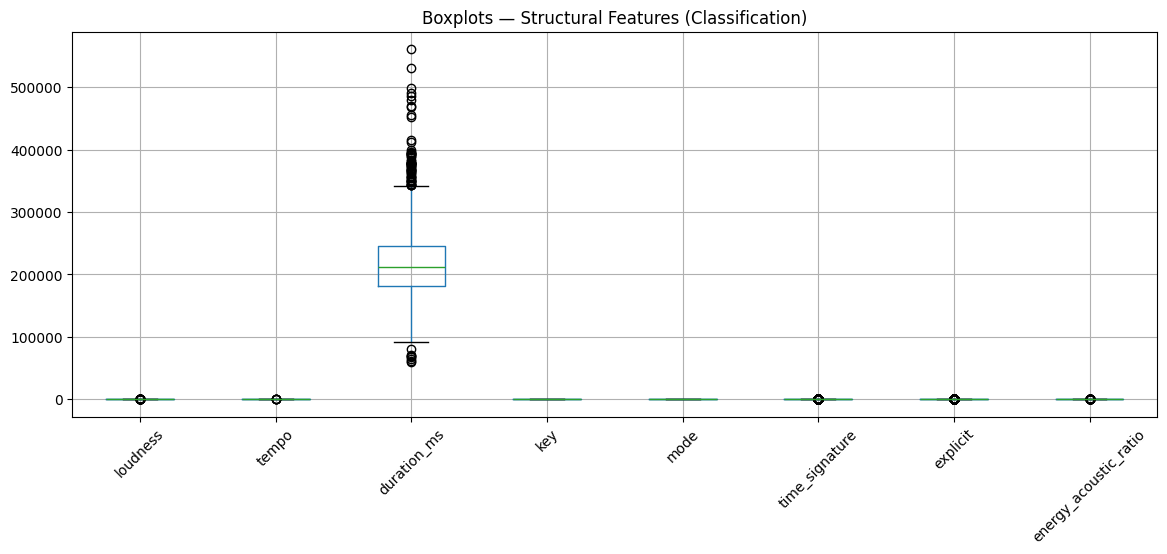

In [ ]:
# Structural/metadata features
struct_cols = ["loudness","tempo","duration_ms","key","mode","time_signature",
               "explicit","energy_acoustic_ratio"]
display(X_class[struct_cols].describe())
X_class[struct_cols].boxplot(figsize=(14, 5))
plt.title("Boxplots — Structural Features (Classification)")
plt.xticks(rotation=45)
plt.show()

#TODO double check if these boxplots are right

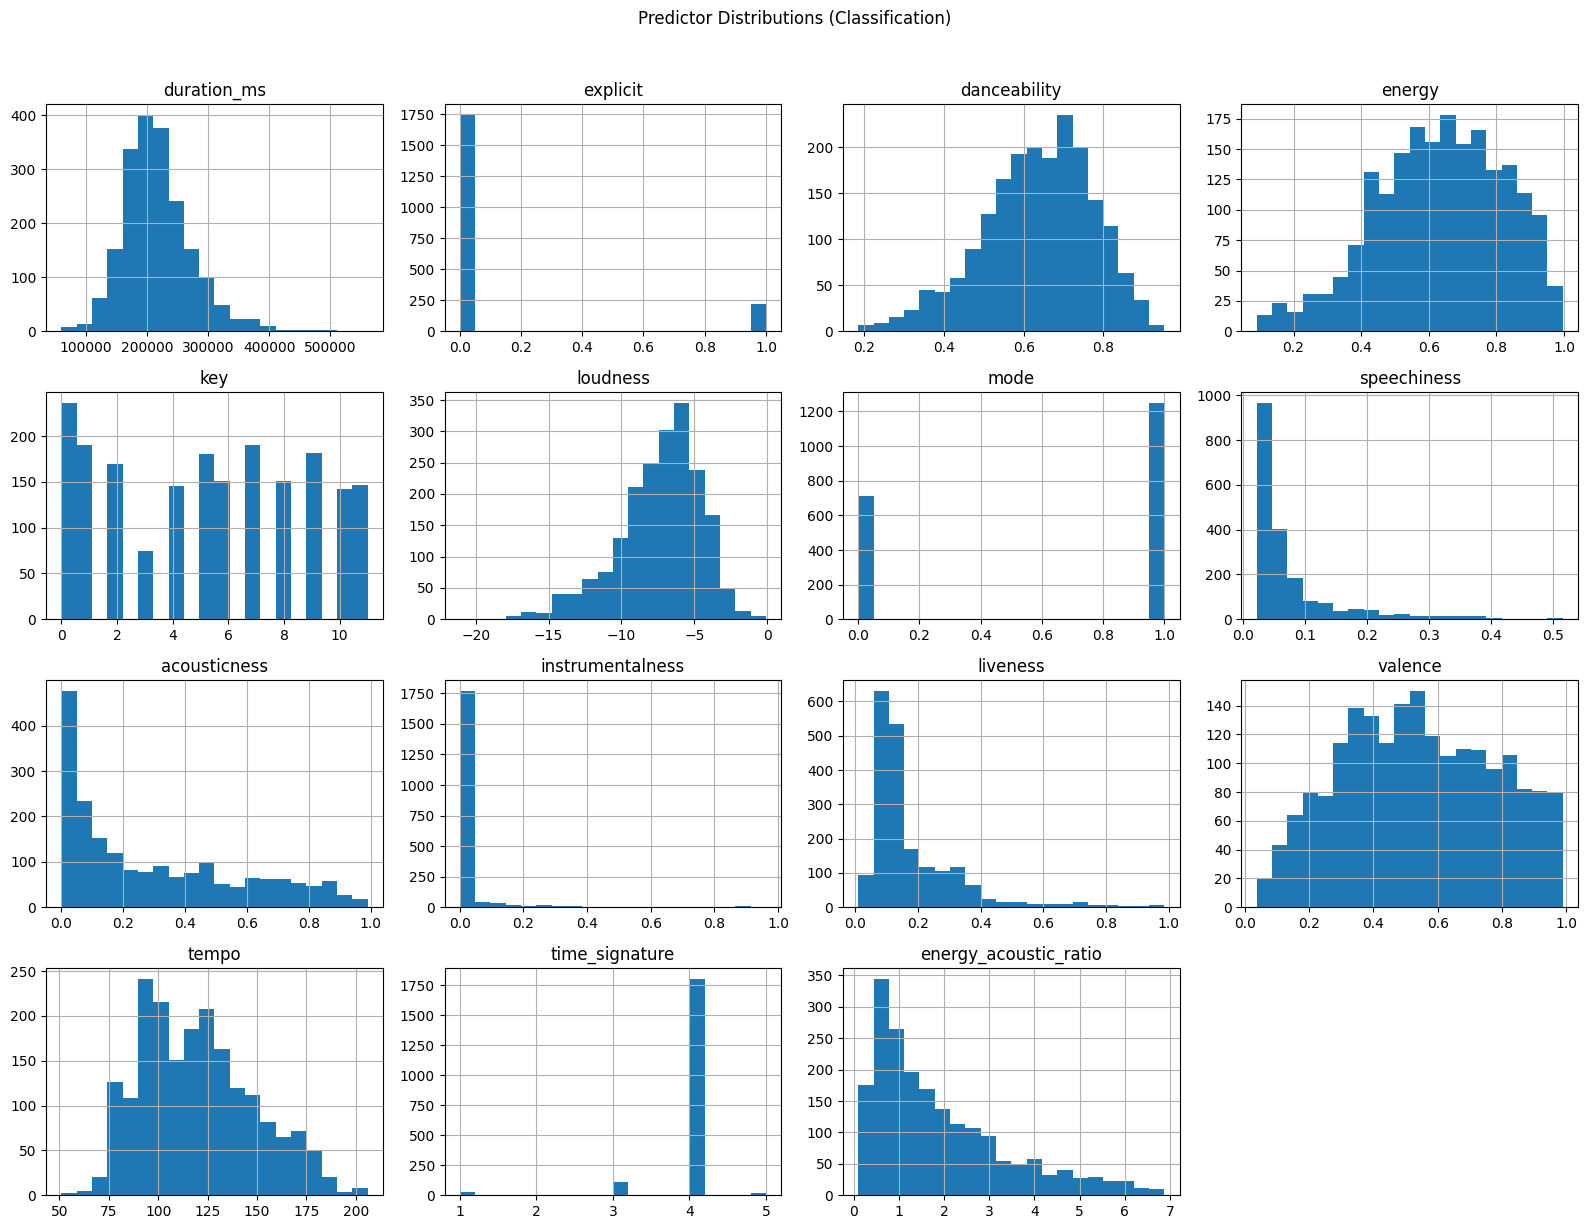

In [ ]:
#Histograms of all predictors
X_class.select_dtypes(include=np.number).hist(bins=20, figsize=(16, 12))
plt.suptitle("Predictor Distributions (Classification)", y=1.02)
plt.tight_layout()
plt.show()
# TODO a couple of strange histograms here, do they need change?

### 4.2 Data Preparation for Classification

In [ ]:
#Partition predictors into groups for different preprocessing
# group 1: highly skewed — log transform + RobustScaler
columns_log_robust = ["speechiness", "instrumentalness", "liveness",
                      "duration_ms", "energy_acoustic_ratio"]

# group 2: has outlier (loudness) but no skew issue — RobustScaler only
columns_robust_only = ["loudness"]

# group 3: categorical integers — one-hot encode
columns_ohe = ["key", "time_signature"]

#group 4: remaining numerical — StandardScaler
columns_standard = [c for c in X_class.select_dtypes(include=np.number).columns
                    if c not in columns_log_robust + columns_robust_only + columns_ohe]

print("Log+Robust cols:", columns_log_robust)
print("Robust-only cols:", columns_robust_only)
print("OHE cols:", columns_ohe)
print("Standard cols:", columns_standard)

Log+Robust cols: ['speechiness', 'instrumentalness', 'liveness', 'duration_ms', 'energy_acoustic_ratio']
Robust-only cols: ['loudness']
OHE cols: ['key', 'time_signature']
Standard cols: ['explicit', 'danceability', 'energy', 'mode', 'acousticness', 'valence', 'tempo']


In [ ]:
# Builds preprocessing pipeline
log_robust_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scaler", RobustScaler())
])
robust_only_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

standard_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

class_preprocess = ColumnTransformer(
    transformers=[
        ("log_robust", log_robust_pipeline,  columns_log_robust),
        ("robust_only", robust_only_pipeline, columns_robust_only),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), columns_ohe),
        ("standard", standard_pipeline, columns_standard)
    ]
)

#Pipline diagram
set_config(display="diagram")
class_preprocess

ColumnTransformer(transformers=[('log_robust',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', RobustScaler())]),
                                 ['speechiness', 'instrumentalness', 'liveness',
                                  'duration_ms', 'energy_acoustic_ratio']),
                                ('robust_only',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['loudness']),
                                ('ohe',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['key', 'time_signature']),
                                ('standard',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['explicit', 'danceability', 'energy', 'mode',
                                  'acousticness', 'valence', 'tempo'])])

In [ ]:
# Train/test split 
#stratify=y to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, shuffle=True,
    stratify=y_class, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} examples")
print(f"Test set: {X_test.shape[0]} examples")

Training set: 1568 examples
Test set:     392 examples


### 4.3 Model Training with Cross-Validation

In [122]:
# 10-fold stratified CV and scoring metrics
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "Accuracy": "accuracy",
    "F1-score": "f1",
    "Precision": "precision",
    "Recall": "recall",
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

In [ ]:
#Model 1: Logistic Regression pipeline
pipe_lr = Pipeline(steps=[
    ("preprocess", class_preprocess),
    ("lr", LogisticRegression(max_iter=1000))
])

set_config(display="diagram")
pipe_lr

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('log_robust',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['speechiness',
                                                   'instrumentalness',
                                                   'liveness', 'duration_ms',
                                                   'energy_acoustic_ratio']),
                                                 ('robust_only',
                                                  Pipeline(steps=[('imputer'...
                                                                   RobustScaler())]),
                                                  ['loudness']),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['key', 'time_signature']),
                                                 ('standard',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['explicit', 'danceability',
                                                   'energy', 'mode',
                                                   'acousticness', 'valence',
                                                   'tempo'])])),
                ('lr', LogisticRegression(max_iter=1000))])

In [124]:
param_grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"],
    "lr__solver": ["liblinear"]
}

lr_search = GridSearchCV(
    pipe_lr, param_grid_lr,
    n_jobs=-1, cv=cv, scoring=scoring,
    refit="F1-score", return_train_score=False
)

lr_search.fit(X_train, y_train)
print(f"Best CV F1 = {lr_search.best_score_:.3f}")
print("Best parameters:", lr_search.best_params_)

LR_best_model  = lr_search.best_estimator_
LR_best_cv_f1  = lr_search.best_score_

Best CV F1 = 0.581
Best parameters: {'lr__C': 0.1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}


In [ ]:
# Model 2: Random Forest pipeline
pipe_rf = Pipeline(steps=[
    ("preprocess", class_preprocess),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE))
])

set_config(display="diagram")
pipe_rf

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('log_robust',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['speechiness',
                                                   'instrumentalness',
                                                   'liveness', 'duration_ms',
                                                   'energy_acoustic_ratio']),
                                                 ('robust_only',
                                                  Pipeline(steps=[('imputer'...
                                                                   RobustScaler())]),
                                                  ['loudness']),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['key', 'time_signature']),
                                                 ('standard',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['explicit', 'danceability',
                                                   'energy', 'mode',
                                                   'acousticness', 'valence',
                                                   'tempo'])])),
                ('rf', RandomForestClassifier(random_state=42))])

In [ ]:
param_grid_rf = {
    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [4, 8, 12, None]
}

rf_search = GridSearchCV(
    pipe_rf, param_grid_rf,
    n_jobs=-1, cv=cv, scoring=scoring,
    refit="F1-score", return_train_score=False
)
rf_search.fit(X_train, y_train)
print(f"Best CV F1 = {rf_search.best_score_:.3f}")
print("Best parameters:", rf_search.best_params_)
RF_best_model  = rf_search.best_estimator_
RF_best_cv_f1  = rf_search.best_score_

Best CV F1 = 0.667
Best parameters: {'rf__max_depth': 12, 'rf__n_estimators': 200}


### 4.4 Cross-Validated Model Comparison (Training Set Only)

In [ ]:
#Compute CV metrcs (mean ± std) for both best models
class_models = {
    "Logistic Regression (best by F1)": LR_best_model,
    "Random Forest (best by F1)": RF_best_model
}

cv_results_class = {}
for name, model in class_models.items():
    res = cross_validate(model, X_train, y_train,
                         cv=cv, scoring=scoring,
                         return_train_score=False, n_jobs=-1)
    cv_results_class[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

for name, metrics_dict in cv_results_class.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        print(f"  {m:9s}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}")


Logistic Regression (best by F1)
  Accuracy : mean=0.579, std=0.034
  F1-score : mean=0.582, std=0.042
  Precision: mean=0.571, std=0.035
  Recall   : mean=0.598, std=0.067
  ROC_AUC  : mean=0.599, std=0.028
  AP       : mean=0.589, std=0.044

Random Forest (best by F1)
  Accuracy : mean=0.663, std=0.026
  F1-score : mean=0.667, std=0.024
  Precision: mean=0.651, std=0.029
  Recall   : mean=0.686, std=0.039
  ROC_AUC  : mean=0.730, std=0.025
  AP       : mean=0.697, std=0.034


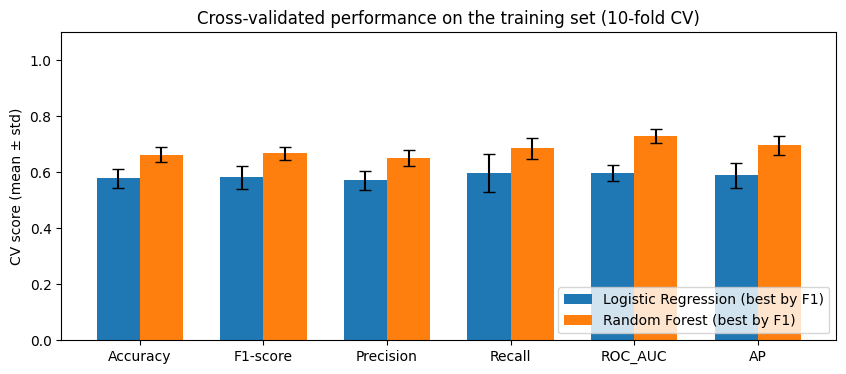

In [ ]:
# Bar chart of CV metrics with error bars
metric_names = list(scoring.keys())
labels = list(cv_results_class.keys())
means = {lab: [np.mean(cv_results_class[lab][m]) for m in metric_names] for lab in labels}
stds  = {lab: [np.std(cv_results_class[lab][m])  for m in metric_names] for lab in labels}

x = np.arange(len(metric_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, means[labels[0]], width, yerr=stds[labels[0]], capsize=4, label=labels[0])
ax.bar(x + width/2, means[labels[1]], width, yerr=stds[labels[1]], capsize=4, label=labels[1])
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("Cross-validated performance on the training set (10-fold CV)")
ax.legend(loc="lower right")
plt.show()

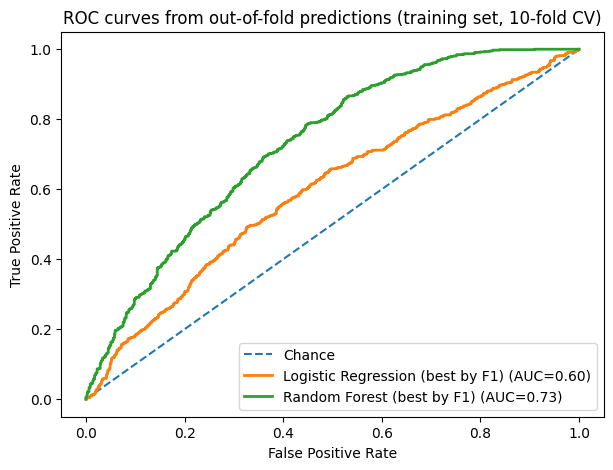

In [ ]:
# ROC curves from out-of-fold predictions
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

for name, model in class_models.items():
    oof_proba = cross_val_predict(model, X_train, y_train,
                                  cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    fpr, tpr, _ = roc_curve(y_train, oof_proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower right")
plt.show()

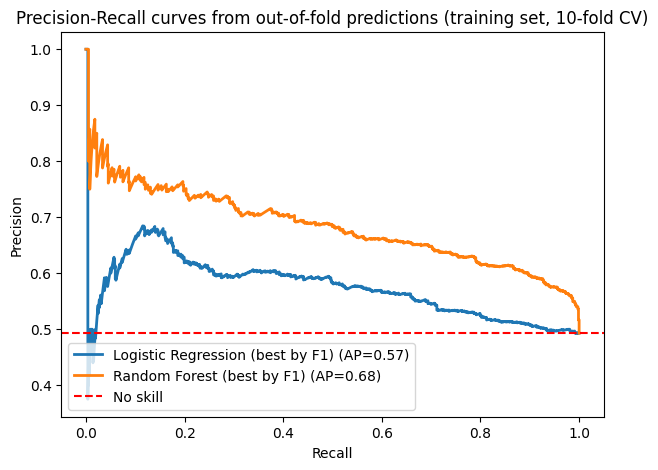

In [ ]:
# Precision-Recall curves from out-of-fold predictions
plt.figure(figsize=(7, 5))
for name, model in class_models.items():
    oof_proba = cross_val_predict(model, X_train, y_train,
                                  cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    prec, rec, _ = precision_recall_curve(y_train, oof_proba)
    ap = average_precision_score(y_train, oof_proba)
    plt.plot(rec, prec, lw=2, label=f"{name} (AP={ap:.2f})")

plt.axhline(y=y_train.mean(), color="red", linestyle="--", label="No skill")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower left")
plt.show()

In [ ]:
# Final model selection based on CV F1
if LR_best_cv_f1 >= RF_best_cv_f1:
    best_class_name  = "Logistic Regression"
    best_class_model = LR_best_model
    best_class_cv_f1 = LR_best_cv_f1
else:
    best_class_name  = "Random Forest"
    best_class_model = RF_best_model
    best_class_cv_f1 = RF_best_cv_f1

print(f"Chosen model: {best_class_name} (mean CV F1 = {best_class_cv_f1:.3f})")

Chosen model: Random Forest (mean CV F1 = 0.667)


### 4.5 Final Evaluation on the Test Set

In [ ]:
#Evaluation function
def evaluate_model(X_eval, y_eval, model):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predicted = model.predict(X_eval)
    results = {
        "confusion_matrix": confusion_matrix(y_eval, predicted),
        "accuracy": accuracy_score(y_eval, predicted),
        "precision": precision_score(y_eval, predicted, zero_division=0),
        "recall": recall_score(y_eval, predicted, zero_division=0),
        "f1": f1_score(y_eval, predicted, zero_division=0)
    }
    fpr, tpr, _ = roc_curve(y_eval, probabilities)
    results["fpr"] = fpr; 
    results["tpr"] = tpr
    results["auc"] = auc(fpr, tpr)
    prc_p, prc_r, _ = precision_recall_curve(y_eval, probabilities)
    results["prc_precision"] = prc_p; results["prc_recall"] = prc_r
    results["ap"] = average_precision_score(y_eval, probabilities)
    return results

test_results = evaluate_model(X_test, y_test, best_class_model)

In [ ]:
#Confusion matrix
cm_df = pd.DataFrame(
    test_results["confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
print("Confusion Matrix (Test Set):")
display(cm_df)

Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,138,61
Actual 1,61,132


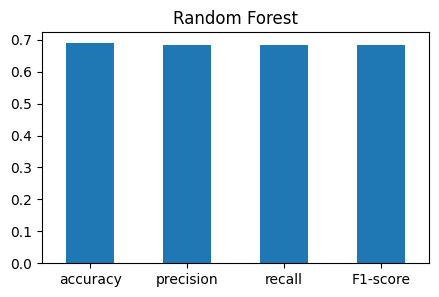

In [ ]:
# Metrics bar chart
metrics_arr = np.array([test_results["accuracy"], test_results["precision"],
                        test_results["recall"],   test_results["f1"]])
df_metrics = pd.DataFrame({best_class_name: metrics_arr},
                           index=["accuracy","precision","recall","F1-score"])
df_metrics.plot.bar(rot=0, figsize=(5,3), legend=False, title=best_class_name)
plt.show() #TODO check these values make sense

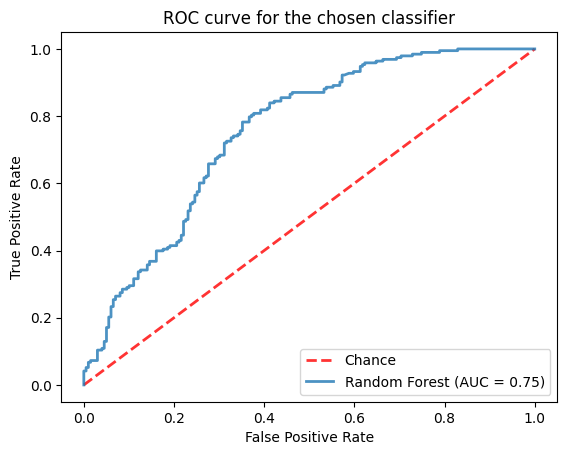

In [ ]:
# ROC curve on test set
plt.plot([0,1],[0,1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)
plt.plot(test_results["fpr"], test_results["tpr"], lw=2,
         label=f"{best_class_name} (AUC = {test_results['auc']:.2f})", alpha=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve for the chosen classifier")
plt.legend(loc="lower right")
plt.show()

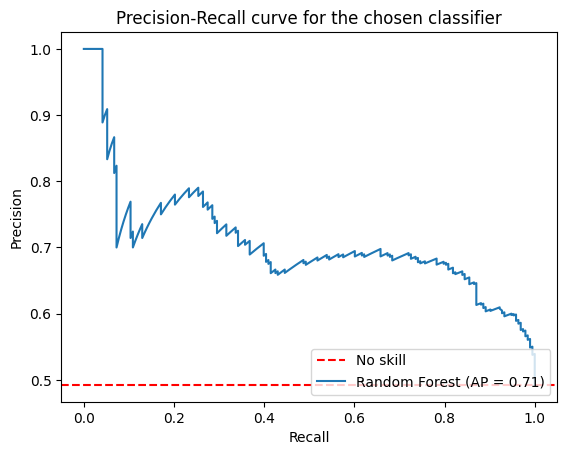

In [ ]:
# Precision-Recall curve on test set
plt.axhline(y=y_test.mean(), color="red", linestyle="--", label="No skill")
plt.plot(test_results["prc_recall"], test_results["prc_precision"],
         label=f"{best_class_name} (AP = {test_results['ap']:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve for the chosen classifier")
plt.legend(loc="lower right")
plt.show()

,feature,importance
28,tempo,0.095115
27,valence,0.087229
0,speechiness,0.083011
3,duration_ms,0.082497
5,loudness,0.081834
2,liveness,0.081514
26,acousticness,0.081251
23,danceability,0.080985
4,energy_acoustic_ratio,0.079909
24,energy,0.077457


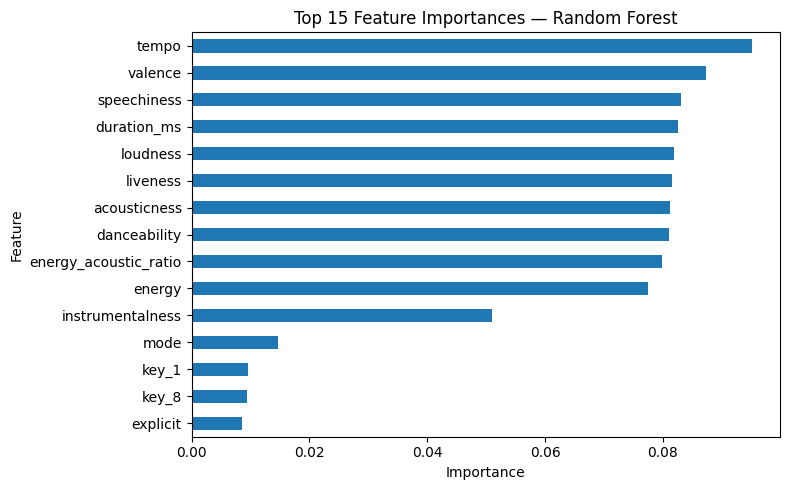

In [ ]:
# Feature importance for Random Forest (always show for RF skip for LR uses coefficients)
if best_class_name == "Random Forest":
    def get_preprocessor_feature_names(preprocessor):
        feature_names = []
        for name, transformer, cols in preprocessor.transformers_:
            if transformer == "drop":
                continue
            if transformer == "passthrough":
                feature_names.extend(cols if cols != "remainder" else list(preprocessor.feature_names_in_))
                continue

            if isinstance(transformer, Pipeline):
                final_estimator = transformer.steps[-1][1]
                if hasattr(final_estimator, "get_feature_names_out"):
                    feature_names.extend(final_estimator.get_feature_names_out(cols))
                elif hasattr(transformer, "get_feature_names_out"):
                    feature_names.extend(transformer.get_feature_names_out(cols))
                else:
                    feature_names.extend(cols)
            elif hasattr(transformer, "get_feature_names_out"):
                feature_names.extend(transformer.get_feature_names_out(cols))
            else:
                feature_names.extend(cols)

        return np.array(feature_names)

    feature_names = get_preprocessor_feature_names(best_class_model.named_steps["preprocess"])

    if best_class_name == "Random Forest":
        importances = best_class_model.named_steps["rf"].feature_importances_
    else:
        importances = np.abs(best_class_model.named_steps["lr"].coef_[0])
    importances   = best_class_model.named_steps["rf"].feature_importances_
else:
    feature_names = best_class_model.named_steps["preprocess"].get_feature_names_out()
    importances   = np.abs(best_class_model.named_steps["lr"].coef_[0])

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
display(importance_df.head(15))

importance_df.head(15).sort_values("importance").plot(
    kind="barh", x="feature", y="importance", legend=False, figsize=(8,5))
plt.title(f"Top 15 Feature Importances — {best_class_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Save best classification model
pickle.dump(best_class_model, open("best_classification_model.sav", "wb"))
print("Model saved.")

Model saved.


**→ Quick conclusion for section 4 to add here** Discuss:
- Why F1 was chosen as the selection metric.
- Which model performed better and why.
- What the ROC/PR curves tell you about discrimination ability.
- Which features were most important and what that means for this task.

## 5. Regression — Predicting Popularity Score

### 5.1 EDA for Regression

In [ ]:
# Separate copy with original popularity retained
reg_df = df_clean.copy()

#Genre distribution in the regression dataset
print("Genre distribution:")
display(reg_df["track_genre"].value_counts())

# Check for zeros that could be missing values
print("\nTracks with popularity == 0:", (reg_df["popularity"] == 0).sum())
print("These are legitimate very-unpopular tracks, not missing values.")
print("The 40 true missing rows were already dropped in data cleaning.")
display(reg_df[reg_df["popularity"] == 0].head(3))

Genre distribution:


track_genre
indie-pop    494
pop          488
synth-pop    393
r-n-b        293
hip-hop      292
Name: count, dtype: int64


Tracks with popularity == 0: 422
These are legitimate very-unpopular tracks, not missing values.
The 40 true missing rows were already dropped in data cleaning.


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,energy_acoustic_ratio
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.0,0.2640,0.716,90.959,4,indie-pop,2.808360
6,0.0,152000,0,0.712,0.251,6,-12.412,1,0.0473,0.8070,0.0,0.1080,0.627,79.956,5,indie-pop,0.270518
27,0.0,156265,0,0.637,0.705,10,-7.546,0,0.0502,0.1210,0.0,0.0857,0.553,158.013,4,indie-pop,1.913784


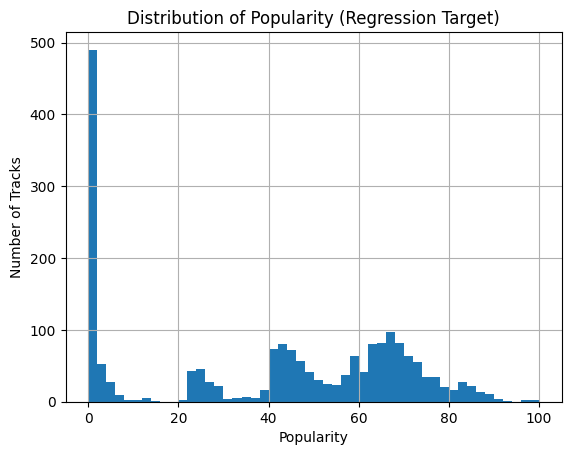

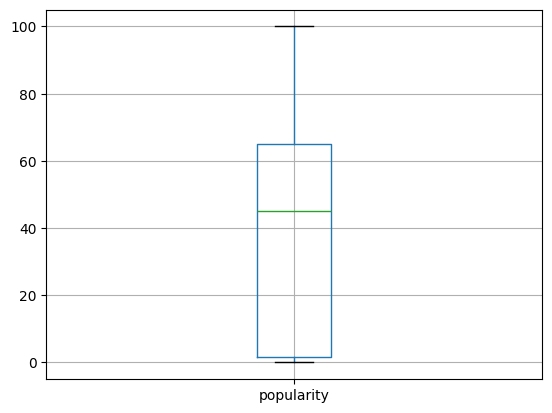

Basic statistics of the target variable:


count    1960.000000
mean       39.805102
std        29.245904
min         0.000000
25%         1.750000
50%        45.000000
75%        65.000000
max       100.000000
Name: popularity, dtype: float64

In [ ]:
# Target variable: distribution and boxplot
reg_df["popularity"].hist(bins=50)
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")
plt.title("Distribution of Popularity (Regression Target)")
plt.show()
reg_df.boxplot(column=["popularity"])
plt.show()
print("Basic statistics of the target variable:")
display(reg_df["popularity"].describe())

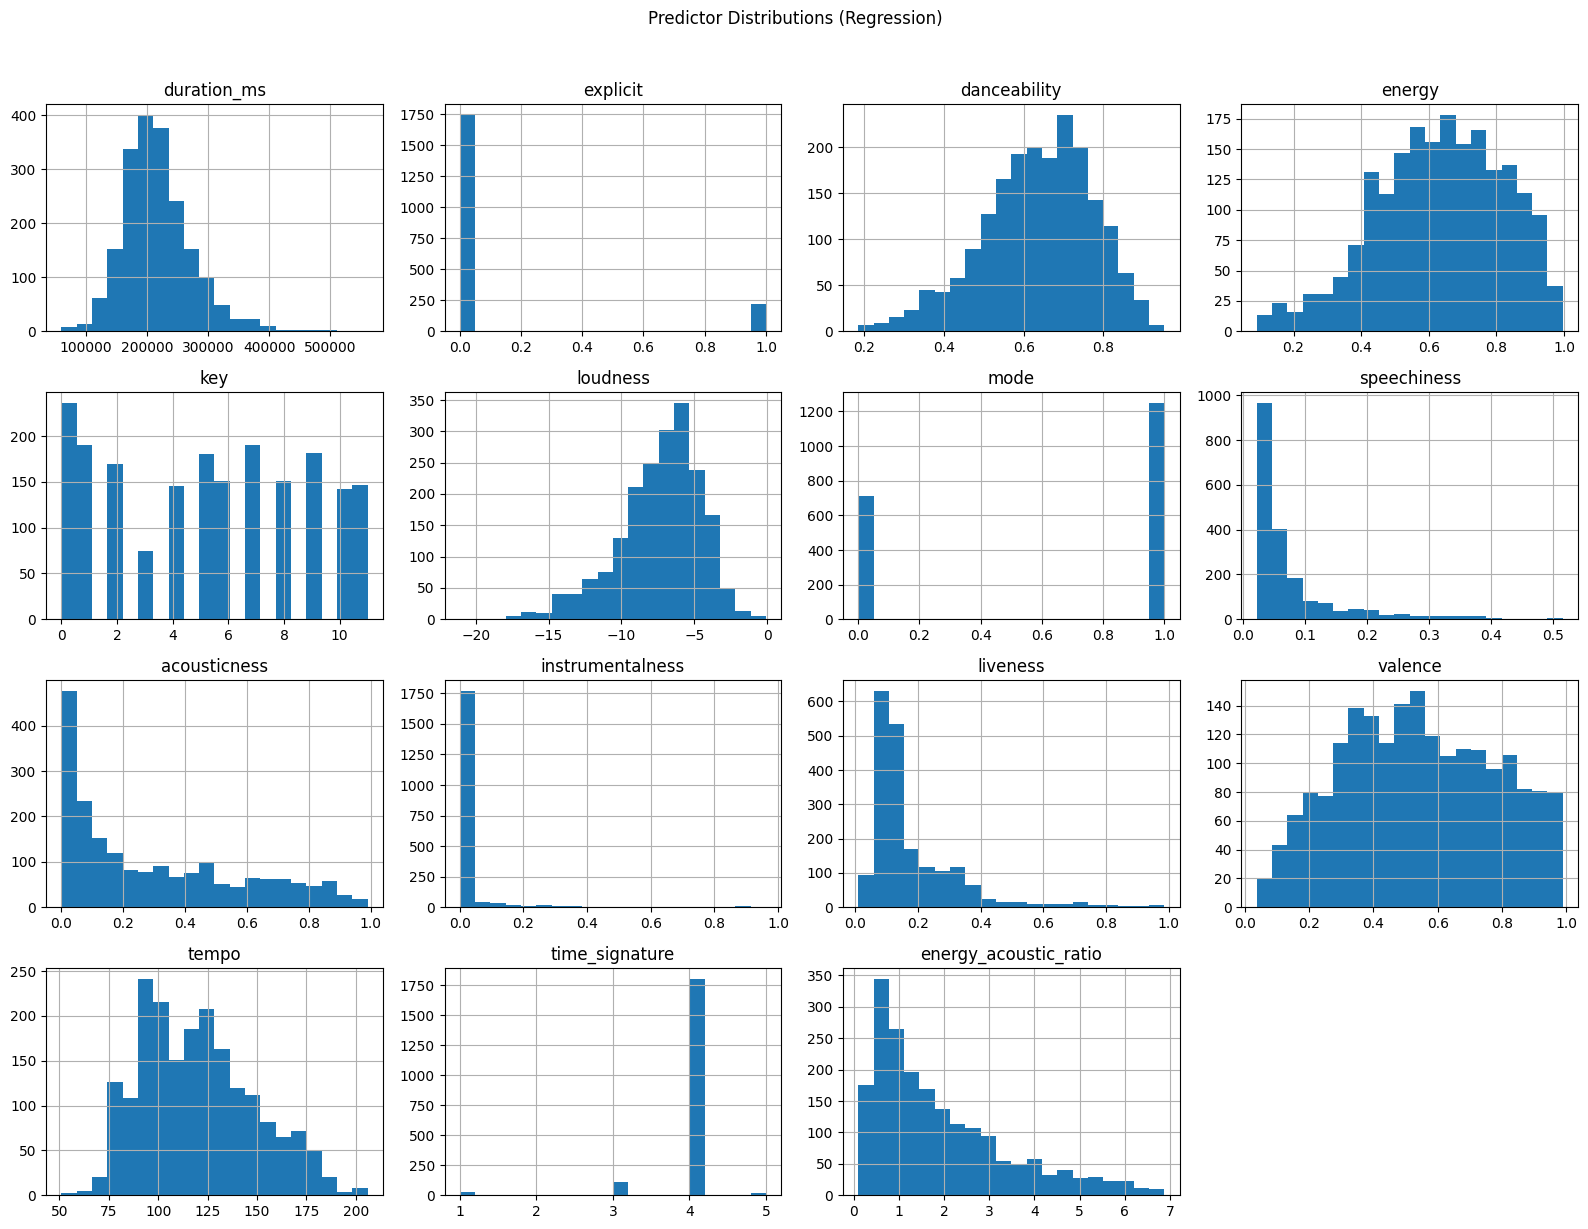

In [ ]:
# Predictor histograms without the target
X_reg = reg_df.drop(columns=["popularity", "track_genre"])
y_reg = reg_df["popularity"]

X_reg.select_dtypes(include=np.number).hist(bins=20, figsize=(16, 12))
plt.suptitle("Predictor Distributions (Regression)", y=1.02)
plt.tight_layout()
plt.show() #TODO verify these histograms

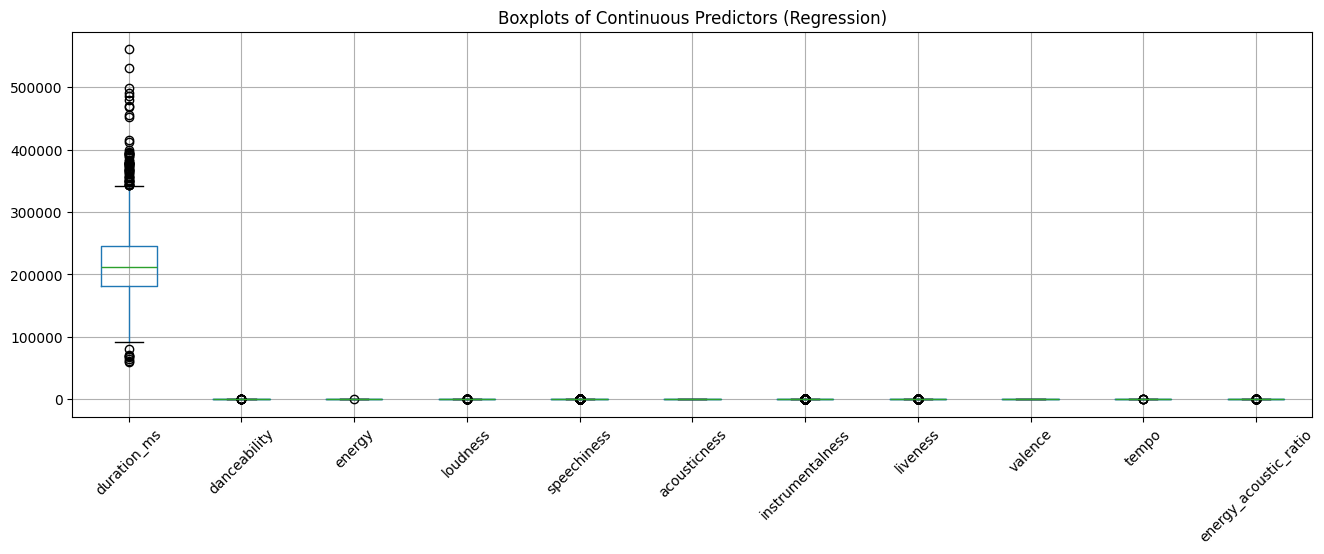


Basic statistics:


,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,energy_acoustic_ratio
count,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000
mean,217716.381122,0.111224,0.635897,0.632489,5.284694,-7.383006,0.636735,0.078251,0.298259,0.030313,0.181199,0.539731,120.040092,3.911735,1.909568
std,56875.302052,0.314490,0.138298,0.189087,3.556669,2.876789,0.481063,0.076115,0.280367,0.120463,0.150613,0.236181,28.520528,0.428520,1.488776
min,60000.000000,0.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000,0.097353
25%,181201.500000,0.000000,0.548000,0.507750,2.000000,-8.988750,0.000000,0.034400,0.052475,0.000000,0.093800,0.353000,96.956000,4.000000,0.743857
50%,211271.500000,0.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047400,0.195500,0.000007,0.121500,0.534500,118.711500,4.000000,1.451995
75%,245986.750000,0.000000,0.738000,0.780000,8.000000,-5.392250,1.000000,0.083925,0.491250,0.000647,0.222000,0.729000,139.746250,4.000000,2.671008
max,561133.000000,1.000000,0.953000,0.996000,11.000000,-0.079000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000,6.880406


In [ ]:
# Predictor boxplots without target
X_reg.select_dtypes(include=np.number).drop(
    columns=["key","mode","time_signature","explicit"]).boxplot(figsize=(16, 5))
plt.title("Boxplots of Continuous Predictors (Regression)")
plt.xticks(rotation=45)
plt.show()

print("\nBasic statistics:")
display(X_reg.describe()) #TODO do these make sense, or do we drop it?

### 5.2 Data Preparation for Regression

In [ ]:
# Same column grouping as classification
reg_log_robust = ["speechiness","instrumentalness","liveness","duration_ms","energy_acoustic_ratio"]
reg_robust_only = ["loudness"]
reg_ohe = ["key","time_signature"]
reg_standard = [c for c in X_reg.select_dtypes(include=np.number).columns
                   if c not in reg_log_robust + reg_robust_only + reg_ohe]

reg_preprocess = ColumnTransformer(
    transformers=[
        ("log_robust", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("log_transform", FunctionTransformer(np.log1p)),
            ("scaler", RobustScaler())
        ]), reg_log_robust),
        ("robust_only", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), reg_robust_only),
        ("ohe", OneHotEncoder(drop="first", sparse_output=False,
                                      handle_unknown="ignore"), reg_ohe),
        ("standard", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), reg_standard)
    ]
).set_output(transform="pandas")

# Inspect transformed output
X_transformed = reg_preprocess.fit_transform(X_reg)
display(X_transformed.head())
display(X_transformed.tail())

,log_robust__speechiness,log_robust__instrumentalness,log_robust__liveness,log_robust__duration_ms,log_robust__energy_acoustic_ratio,robust_only__loudness,ohe__key_1,ohe__key_2,ohe__key_3,ohe__key_4,...,ohe__time_signature_3,ohe__time_signature_4,ohe__time_signature_5,standard__explicit,standard__danceability,standard__energy,standard__mode,standard__acousticness,standard__valence,standard__tempo
0,-0.418492,-0.010363,0.249932,-0.125232,-0.359036,0.953983,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.353756,-0.201767,-0.420492,0.755323,0.338005,0.005376,0.840062
1,0.138373,0.025675,0.100010,-0.038716,0.217507,0.650076,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,-0.353756,1.006074,-0.103097,-1.323937,-0.675212,1.089567,-0.700520
2,-0.331233,0.006187,1.429284,0.708688,-0.158785,-0.589184,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,1.165191,-0.108387,-1.323937,-0.097250,1.606251,-0.065867
3,2.783162,-0.010363,1.079250,-0.317469,0.591505,0.947310,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,-0.389814,1.039527,0.755323,-0.877856,0.746522,-1.019915
4,-0.075669,0.013611,-0.595249,0.964428,-0.076140,0.068956,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,-0.353756,0.499794,0.425896,-1.323937,-0.136495,-0.176734,0.345766


,log_robust__speechiness,log_robust__instrumentalness,log_robust__liveness,log_robust__duration_ms,log_robust__energy_acoustic_ratio,robust_only__loudness,ohe__key_1,ohe__key_2,ohe__key_3,ohe__key_4,...,ohe__time_signature_3,ohe__time_signature_4,ohe__time_signature_5,standard__explicit,standard__danceability,standard__energy,standard__mode,standard__acousticness,standard__valence,standard__tempo
1995,0.293986,-0.010363,0.964309,0.755239,0.241884,1.080773,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,1.143493,1.515621,0.755323,-0.514667,1.792597,0.473812
1996,-0.308438,169.740478,-0.244643,0.180213,0.036943,-0.436257,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,0.224955,-0.018458,0.755323,-0.439746,-0.358845,-0.176693
1997,0.075402,-0.010363,-0.109269,-0.868563,0.471001,0.114556,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,-0.686350,0.637493,0.755323,-0.822557,0.136665,1.041723
1998,6.537799,-0.010363,0.781730,-1.850542,-0.080529,0.131517,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,1.570216,-0.642669,-1.323937,-0.393367,1.081096,-1.047551
1999,-0.174235,-0.003124,1.470390,0.471527,-0.558763,-1.021827,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,0.796329,-0.330563,0.755323,1.311978,0.496650,-0.354610


In [ ]:
#Train/test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, shuffle=True, random_state=RANDOM_STATE
)
print(f"Training set: {Xr_train.shape[0]} examples")
print(f"Test set: {Xr_test.shape[0]} examples")

Training set: 1568 examples
Test set:     392 examples


### 5.3 Model Training with Cross-Validation

In [ ]:
# 10-fold CV and scoring for regression
cv10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring_reg = {
    "neg_MSE": "neg_mean_squared_error",
    "neg_RMSE": "neg_root_mean_squared_error",
    "neg_MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

In [ ]:
# Model 1: Random Forest with dimensionality reduction
pipe_rfr = Pipeline(steps=[
    ("preprocess", reg_preprocess),
    ("reduce_dim", "passthrough"),
    ("ttr", TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

N_FEATURES_OPTIONS = [4, 8, 12]
MAX_DEPTH_OPTIONS = [4, 8, 12]

param_grid_rfr = [
    {
        "reduce_dim": [PCA(iterated_power=7)],
        "reduce_dim__n_components": N_FEATURES_OPTIONS,
        "ttr__regressor__max_depth": MAX_DEPTH_OPTIONS
    },
    {
        "reduce_dim": [RFE(svm.SVR(kernel="linear", gamma="auto")),
                       RFE(LinearRegression())],
        "reduce_dim__n_features_to_select": N_FEATURES_OPTIONS,
        "ttr__regressor__max_depth": MAX_DEPTH_OPTIONS
    }
]

rfr_search = GridSearchCV(
    pipe_rfr, param_grid_rfr,
    scoring=scoring_reg, n_jobs=-1,
    cv=cv10, refit="R2", return_train_score=False
)
rfr_search.fit(Xr_train, yr_train)
print(f"Best CV R² = {rfr_search.best_score_:.3f}")
print("Best parameters:", rfr_search.best_params_)
RF_reg_best_model  = rfr_search.best_estimator_
RF_reg_best_cv_r2  = rfr_search.best_score_

Best CV R² = -0.275
Best parameters: {'reduce_dim': PCA(iterated_power=7), 'reduce_dim__n_components': 12, 'ttr__regressor__max_depth': 12}


In [ ]:
#Model 2: Ridge Regression with dimensionality reduction
pipe_ridge = Pipeline(steps=[
    ("preprocess", reg_preprocess),
    ("reduce_dim", "passthrough"),
    ("ttr", TransformedTargetRegressor(
        regressor=Ridge(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

FIT_INTERCEPT_OPTIONS = [False, True]

param_grid_ridge = [
    {
        "reduce_dim": [PCA(iterated_power=7)],
        "reduce_dim__n_components": N_FEATURES_OPTIONS,
        "ttr__regressor__alpha": [0.1, 1.0, 10.0]
    },
    {
        "reduce_dim": [RFE(svm.SVR(kernel="linear", gamma="auto")),
                       RFE(LinearRegression())],
        "reduce_dim__n_features_to_select": N_FEATURES_OPTIONS,
        "ttr__regressor__alpha": [0.1, 1.0, 10.0]
    }
]

ridge_search = GridSearchCV(
    pipe_ridge, param_grid_ridge,
    scoring=scoring_reg, n_jobs=-1,
    cv=cv10, refit="R2", return_train_score=False
)
ridge_search.fit(Xr_train, yr_train)
print(f"Best CV R² = {ridge_search.best_score_:.3f}")
print("Best parameters:", ridge_search.best_params_)
Ridge_best_model = ridge_search.best_estimator_
Ridge_best_cv_r2 = ridge_search.best_score_

Best CV R² = -0.559
Best parameters: {'reduce_dim': RFE(estimator=SVR(gamma='auto', kernel='linear')), 'reduce_dim__n_features_to_select': 12, 'ttr__regressor__alpha': 0.1}


### 5.4 Cross-Validated Model Comparison (Training Set Only)

In [ ]:
# Compute CV metrics (mean ± std) for both best regression models
reg_models = {
    "Random Forest": RF_reg_best_model,
    "Ridge Regression": Ridge_best_model
}

cv_results_reg = {}
negative_metrics_reg = [k for k in scoring_reg if k.startswith("neg_")]
for name, model in reg_models.items():
    res = cross_validate(model, Xr_train, yr_train,
                         cv=cv10, scoring=scoring_reg,
                         return_train_score=False, n_jobs=-1)
    cv_results_reg[name] = {m: res[f"test_{m}"] for m in scoring_reg.keys()}

for name, metrics_dict in cv_results_reg.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        sign = -1 if m in negative_metrics_reg else 1
        label = m.replace("neg_","")
        print(f"{label:5s}: mean={sign*np.mean(vals):.3f}, std={np.std(vals):.3f}")


Random Forest
  MSE  : mean=1085.530, std=84.726
  RMSE : mean=32.922, std=1.286
  MAE  : mean=26.686, std=1.340
  R2   : mean=-0.275, std=0.099

Ridge Regression
  MSE  : mean=1326.325, std=102.148
  RMSE : mean=36.391, std=1.409
  MAE  : mean=31.716, std=1.298
  R2   : mean=-0.559, std=0.132


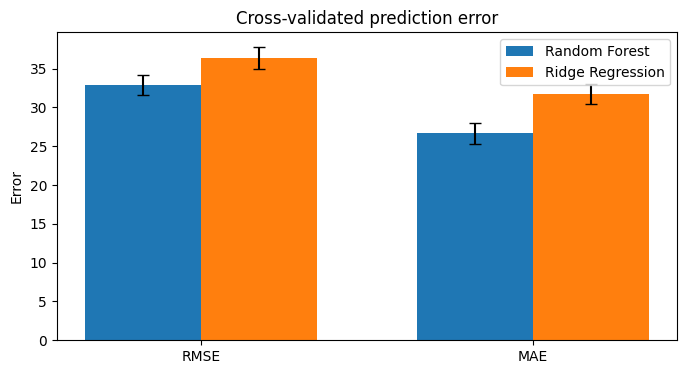

In [ ]:
#RMSE and MAE bar chart
model_names_reg = list(reg_models.keys())
error_metrics = ["neg_RMSE", "neg_MAE"]
display_errors = ["RMSE", "MAE"]

x = np.arange(len(error_metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate(model_names_reg):
    values = [-np.mean(cv_results_reg[name][m]) for m in error_metrics]
    stds = [ np.std(cv_results_reg[name][m]) for m in error_metrics]
    ax.bar(x + (i-0.5)*width, values, width, yerr=stds, capsize=4, label=name)
ax.set_xticks(x); ax.set_xticklabels(display_errors)
ax.set_ylabel("Error"); ax.set_title("Cross-validated prediction error")
ax.legend(); 
plt.show()

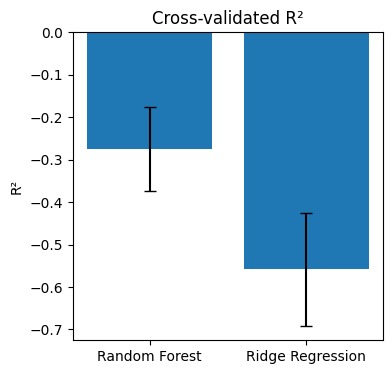

In [ ]:
#R2 bar chart
fig, ax = plt.subplots(figsize=(4, 4))
means_r2 = [np.mean(cv_results_reg[n]["R2"]) for n in model_names_reg]
stds_r2 = [np.std(cv_results_reg[n]["R2"])  for n in model_names_reg]
ax.bar(model_names_reg, means_r2, yerr=stds_r2, capsize=4)
ax.set_ylabel("R^2"); ax.set_title("Cross-validated R^2")
plt.show()

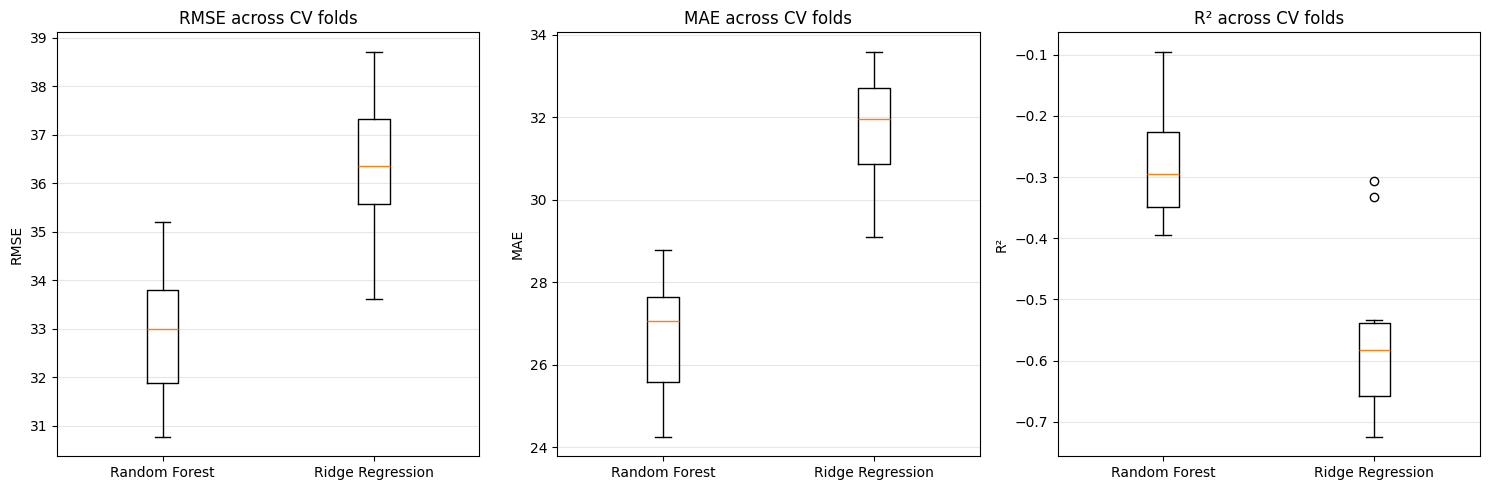

In [ ]:
# Distribution of CV results
rmse_data = [-cv_results_reg[n]["neg_RMSE"] for n in model_names_reg]
mae_data = [-cv_results_reg[n]["neg_MAE"] for n in model_names_reg]
r2_data = [ cv_results_reg[n]["R2"] for n in model_names_reg]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].boxplot(rmse_data, tick_labels=model_names_reg)
axes[0].set_title("RMSE across CV folds"); axes[0].set_ylabel("RMSE"); 
axes[0].grid(axis="y", alpha=0.3)
axes[1].boxplot(mae_data, tick_labels=model_names_reg)
axes[1].set_title("MAE across CV folds"); axes[1].set_ylabel("MAE");  
axes[1].grid(axis="y", alpha=0.3)
axes[2].boxplot(r2_data, tick_labels=model_names_reg)
axes[2].set_title("R² across CV folds"); axes[2].set_ylabel("R²");   
axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout(); 
plt.show()

In [ ]:
# Final model selection based on CV R2
if RF_reg_best_cv_r2 >= Ridge_best_cv_r2:
    best_reg_name = "Random Forest"
    best_reg_model = RF_reg_best_model
    best_reg_cv_r2 = RF_reg_best_cv_r2
else:
    best_reg_name = "Ridge Regression"
    best_reg_model = Ridge_best_model
    best_reg_cv_r2 = Ridge_best_cv_r2

print(f"Chosen model: {best_reg_name} (mean CV R² = {best_reg_cv_r2:.3f})")

Chosen model: Random Forest (mean CV R² = -0.275)


### 5.5 Final Evaluation on the Test Set

In [ ]:
# Test set performance
yr_pred = best_reg_model.predict(Xr_test)

metrics_reg = {
    "MSE": mean_squared_error(yr_test, yr_pred),
    "RMSE": np.sqrt(mean_squared_error(yr_test, yr_pred)),
    "MAE": mean_absolute_error(yr_test, yr_pred),
    "R2": r2_score(yr_test, yr_pred)
}

print("\nTest set performance")
for m, val in metrics_reg.items():
    print(f"  {m:5s}: {val:.3f}")


Test set performance
  MSE  : 1059.992
  RMSE : 32.558
  MAE  : 25.921
  R2   : -0.257


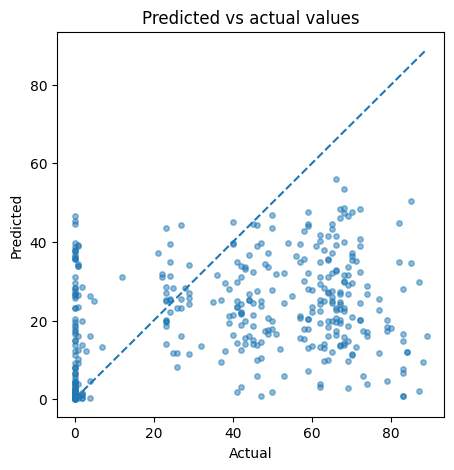

In [ ]:
# Predicted vs actual scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, yr_pred, s=15, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs actual values")
min_val = min(yr_test.min(), yr_pred.min())
max_val = max(yr_test.max(), yr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()
#TODO Is this plot behaving correctly?

In [ ]:
# Save the best regression model
pickle.dump(best_reg_model, open("best_regression_model.sav", "wb"))
print("Regression model saved.")

Regression model saved.


**→ Add our conclusion here** 
Discuss:
- Why R² was chosen as the model selection metric.
- Which model performed better and why.
- Whether predicting exact popularity is harder than predicting high/low popularity.
- What the predicted vs actual scatter plot tells you about the model's limitations.